<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202508_DOE_TRES_FACTORES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño Factorial - Tres factores 2025**


<a name="inicio"></a>


## **1.** [Librerias para Trabar en R y Colab](#T1)
## **2.** [Ejemplo de un diseño factorial Tres Factores](#T2)

## **3.** [Los Datos del Problema](#T3)

## **4.** [BoxPlot para el Diseño Factorial](#T4)

## **5.** [Análisis de Varianza e Interpretación](#T5)

## **6.** [Interpretación del Análisis de Varianza (ANOVA)](#T6)

## **7.** [Gráfico de interacciones entre los factores](#T7)


## **8.** [Comparaciones Múltiples - DCGL - HSD - Para las Formulaciones](#T8)

## **9.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD](#T9)


## **10.** [Comparaciones Múltiples: LSD vs HSD](#T10)

## **11.** [Las diferencias entre las medias entre las formulaciones - Caso 2 poblaciones](#T11)

## **12.** [Supuestos del Modelo : Normalidad](#T12)

## **13.** [Supuestos del Modelo = Homocedasticidad](#T13)


## **14.** [Supuestos del Modelo = Independencia](#T14)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Librerias para Trabar en R y Colab**


In [64]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


[⬆️ Volver al inicio](#inicio)

In [65]:
# @title **B. Librerias para Trabar en R y Colab**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats

from statsmodels.graphics.factorplots import interaction_plot
#!pip install bioinfokit
#from bioinfokit.analys import stat
!pip install pingouin &>/dev/null
import pingouin as pg


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Ejemplo de un diseño factorial Tres Factores**


# **1. Ejemplo de un diseño factorial Tres Factores**

- ***El experimento Se desea investigar el efecto del tipo de suspensión (A), abertura de malla (B) y temperatura de ciclaje (C) en el volumen de sedimentación Y(%) de una suspensión. Para ello se decide correr un experimento factorial 3×2×2 con seis réplicas, y las observaciones obtenidas en las 72 corridas experimentales se muestran en la siguiente tabla:***


| A1 // B | B1| B1 | B1 | B2 | B2| B2|
|:---:| :---: | :---: | :---: | :---: |:---: | :---: |
|	      | 60 | 75 |	75 |	67 | 73 | 73 |
|C1     | 86 | 70 |	70 |	67 | 68 | 68 |
||
|	      | 55 | 53 |	53 |	52 | 52 | 57 |
|C2	    | 55 | 55 |	55 |	52 | 54 | 54 |


| A2 // B | B1| B1 | B1 | B2 | B2| B2|
|:---:| :---: | :---: | :---: | :---: |:---: | :---: |
|	      | 62 | 68 |	65 |	71 | 80 | 80 |
|C1     | 76 | 65 |	65 |	72 | 80 | 80 |
||
|	      | 44 | 44 |	45 |	60 | 60 | 60 |
|C2	    | 48 | 48 |	45 |	67 | 67 | 65 |
    

| A3 // B | B1| B1 | B1 | B2 | B2| B2|
|:---:| :---: | :---: | :---: | :---: |:---: | :---: |
|	      | 70 | 71 |	75 |	75 | 75 | 75 |
|C1     | 76 | 68 |	73 |	75 | 75 | 77 |
||
|	      | 52 | 51 |	50 |	56 | 55 | 57 |
|C2	    | 52 | 48 |	54 |	59 | 50 | 55 |



[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Los Datos del Problema**


In [66]:
#@title **A. Los Datos del Problema del diseño factorial 3x2x2**
import pandas as pd
import numpy as np

# Definir los niveles de los factores
suspension = ['A1'] * 24 + ['A2'] * 24 + ['A3'] * 24
malla = ['B1'] * 12 + ['B2'] * 12 + ['B1'] * 12 + ['B2'] * 12 + ['B1'] * 12 + ['B2'] * 12
temperatura = (['C1'] * 6 + ['C2'] * 6) * 6

# Definir los datos de volumen de sedimentación Y (%)
volumen = [
    # A1, B1, C1
    60, 75, 75, 86, 70, 70,
    # A1, B1, C2
    55, 53, 53, 55, 55, 55,
    # A1, B2, C1
    67, 73, 73, 67, 68, 68,
    # A1, B2, C2
    52, 52, 57, 52, 54, 54,
    # A2, B1, C1
    62, 68, 65, 76, 65, 65,
    # A2, B1, C2
    44, 44, 45, 48, 48, 45,
    # A2, B2, C1
    71, 80, 80, 72, 80, 80,
    # A2, B2, C2
    60, 60, 60, 67, 67, 65,
    # A3, B1, C1
    70, 71, 75, 76, 68, 73,
    # A3, B1, C2
    52, 51, 50, 52, 48, 54,
    # A3, B2, C1
    75, 75, 75, 75, 75, 77,
    # A3, B2, C2
    56, 55, 57, 59, 50, 55
]

# Crear el DataFrame
D3F = pd.DataFrame({
    'Suspension': suspension,
    'Malla': malla,
    'Temperatura': temperatura,
    'volumen': volumen
})



In [67]:
# Mostrar las primeras filas del DataFrame
display(D3F.head(12))


,Suspension,Malla,Temperatura,volumen
0,A1,B1,C1,60
1,A1,B1,C1,75
2,A1,B1,C1,75
3,A1,B1,C1,86
4,A1,B1,C1,70
5,A1,B1,C1,70
6,A1,B1,C2,55
7,A1,B1,C2,53
8,A1,B1,C2,53
9,A1,B1,C2,55


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. BoxPlot para el Diseño Factorial**


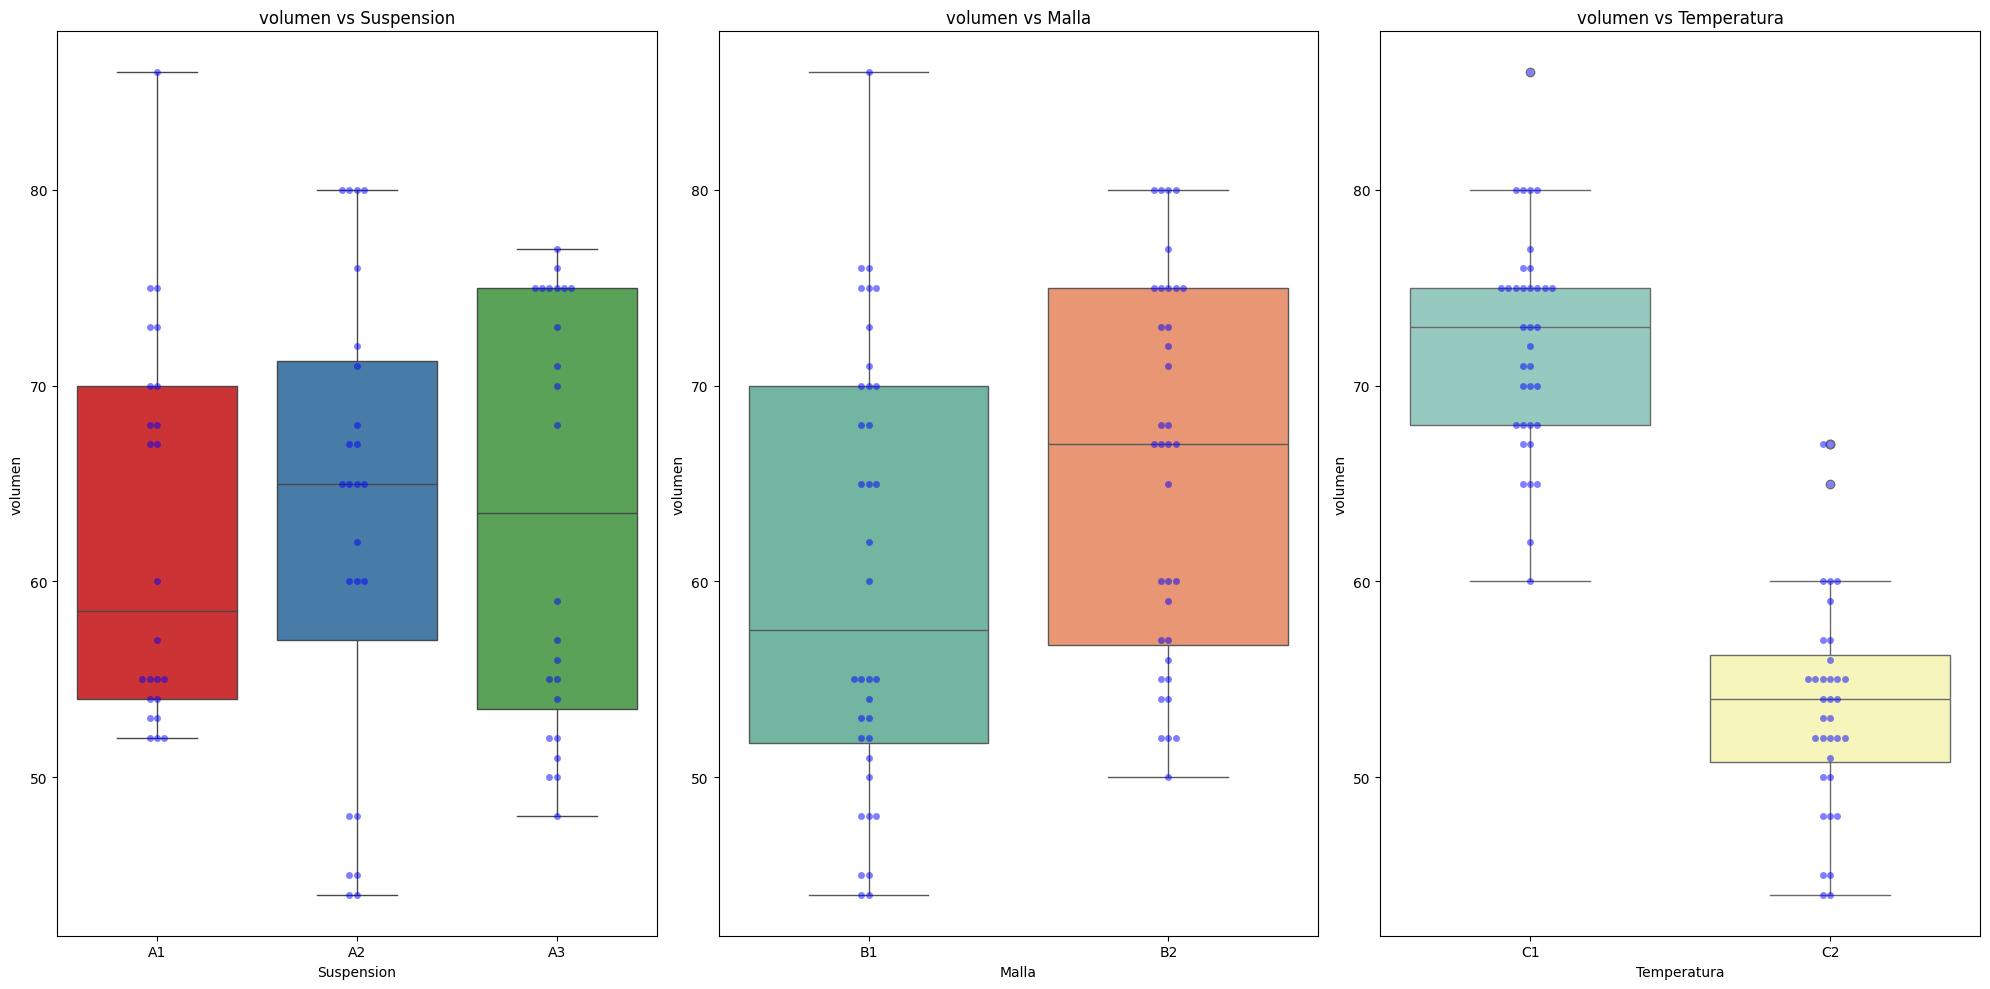

In [68]:
# @title **A. BoxPlot para el D3F - Análisis de volumen por Factores**

fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# Suspension
axs[0].set_title('volumen vs Suspension')
sns.boxplot(x="Suspension", y="volumen", data=D3F, ax=axs[0], palette='Set1',
            hue="Suspension", legend=False)
sns.swarmplot(x="Suspension", y="volumen", data=D3F, color='blue',
              alpha=0.5, ax=axs[0])

# Malla
axs[1].set_title('volumen vs Malla')
sns.boxplot(x="Malla", y="volumen", data=D3F, ax=axs[1], palette='Set2',
            hue="Malla", legend=False)
sns.swarmplot(x="Malla", y="volumen", data=D3F, color='blue',
              alpha=0.5, ax=axs[1])

# Temperatura
axs[2].set_title('volumen vs Temperatura')
sns.boxplot(x="Temperatura", y="volumen", data=D3F, ax=axs[2], palette='Set3',
            hue="Temperatura", legend=False)
sns.swarmplot(x="Temperatura", y="volumen", data=D3F, color='blue',
              alpha=0.5, ax=axs[2])

plt.tight_layout()
plt.show()

D3F.columns


/tmp/ipython-input-1727794818.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box0 = sns.boxplot(x="Suspension", y="volumen", data=D3F, ax=axs[0],
/tmp/ipython-input-1727794818.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box1 = sns.boxplot(x="Malla", y="volumen", data=D3F, ax=axs[1],
/tmp/ipython-input-1727794818.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box2 = sns.boxplot(x="Temperatura", y="volumen", data=D3F, ax=axs[2],


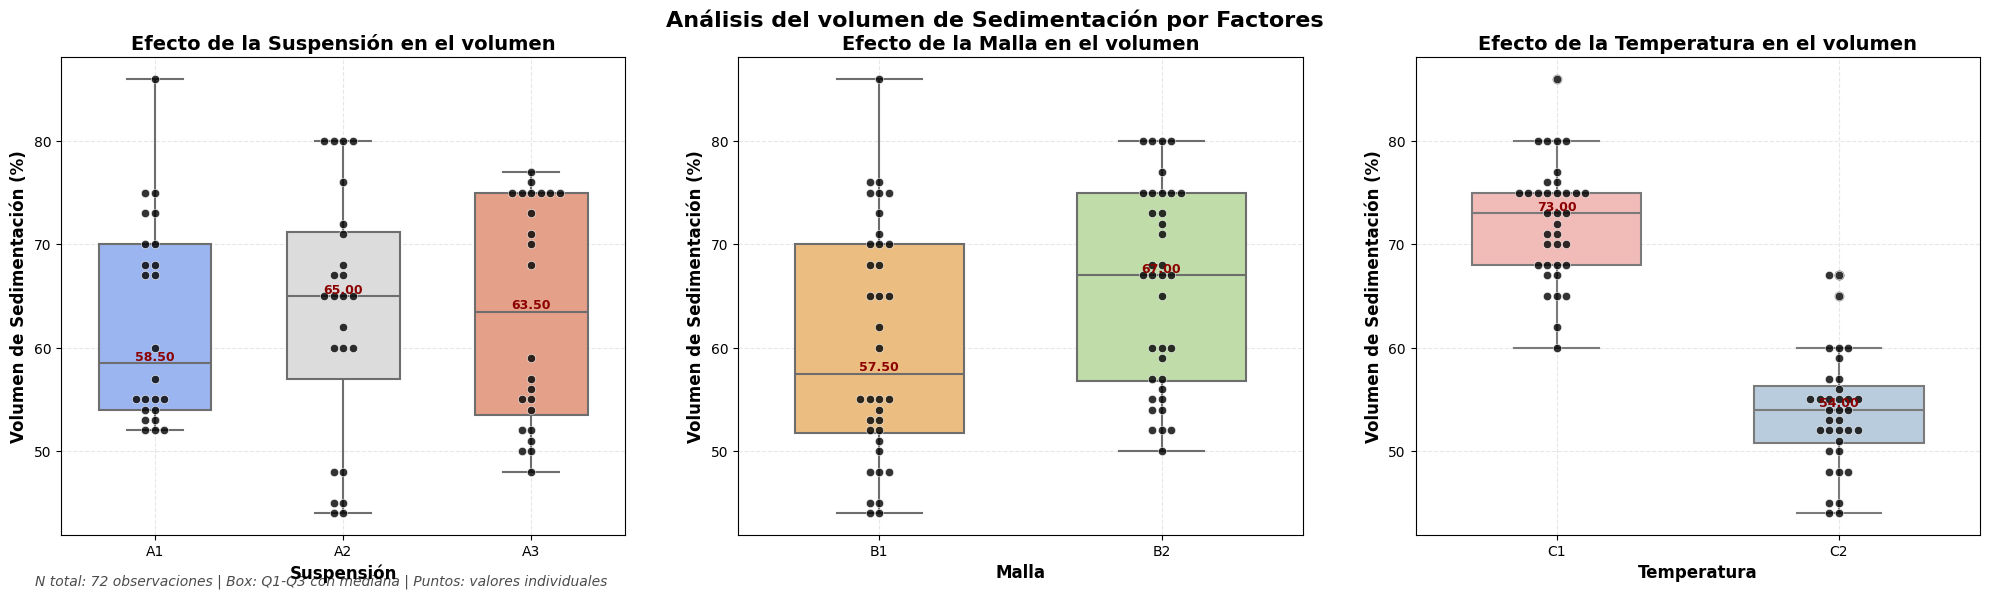


RESUMEN ESTADÍSTICO - volumen DE SEDIMENTACIÓN

Por Suspensión:
            count       mean        std   min   max
Suspension                                         
A1           24.0  62.458333   9.815601  52.0  86.0
A2           24.0  63.208333  12.140407  44.0  80.0
A3           24.0  63.500000  10.874781  48.0  77.0

Por Malla:
       count       mean        std   min   max
Malla                                         
B1      36.0  60.472222  11.450480  44.0  86.0
B2      36.0  65.638889   9.666297  50.0  80.0

Por Temperatura:
             count       mean       std   min   max
Temperatura                                        
C1            36.0  72.250000  5.608030  60.0  86.0
C2            36.0  53.861111  5.737858  44.0  67.0


In [69]:
# @title **B. BoxPlot para el D3F - Análisis de volumen por Factores - Mas completo**
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análisis del volumen de Sedimentación por Factores',
             fontsize=16, fontweight='bold', y=0.98)

# Primer subplot: volumen vs Suspension
axs[0].set_title('Efecto de la Suspensión en el volumen', fontsize=14, fontweight='semibold')
box0 = sns.boxplot(x="Suspension", y="volumen", data=D3F, ax=axs[0],
                  palette='coolwarm', width=0.6, linewidth=1.5)
sns.swarmplot(x="Suspension", y="volumen", data=D3F, color='black',
              size=6, alpha=0.8, edgecolor='white', linewidth=0.5, ax=axs[0])

# Mejorar el primer subplot
axs[0].set_xlabel('Suspensión', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Volumen de Sedimentación (%)', fontsize=12, fontweight='bold')
axs[0].grid(True, alpha=0.3, linestyle='--')
axs[0].tick_params(axis='both', which='major', labelsize=10)


# Segundo subplot: volumen vs Malla
axs[1].set_title('Efecto de la Malla en el volumen', fontsize=14, fontweight='semibold')
box1 = sns.boxplot(x="Malla", y="volumen", data=D3F, ax=axs[1],
                  palette='Spectral', width=0.6, linewidth=1.5)
sns.swarmplot(x="Malla", y="volumen", data=D3F, color='black',
              size=6, alpha=0.8, edgecolor='white', linewidth=0.5, ax=axs[1])

# Mejorar el segundo subplot
axs[1].set_xlabel('Malla', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Volumen de Sedimentación (%)', fontsize=12, fontweight='bold')  # Remover label duplicado
axs[1].grid(True, alpha=0.3, linestyle='--')
axs[1].tick_params(axis='both', which='major', labelsize=10)

# Tercer subplot: volumen vs Temperatura
axs[2].set_title('Efecto de la Temperatura en el volumen', fontsize=14, fontweight='semibold')
box2 = sns.boxplot(x="Temperatura", y="volumen", data=D3F, ax=axs[2],
                  palette='Pastel1', width=0.6, linewidth=1.5)
sns.swarmplot(x="Temperatura", y="volumen", data=D3F, color='black',
              size=6, alpha=0.8, edgecolor='white', linewidth=0.5, ax=axs[2])

# Mejorar el tercer subplot
axs[2].set_xlabel('Temperatura', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Volumen de Sedimentación (%)', fontsize=12, fontweight='bold')
axs[2].grid(True, alpha=0.3, linestyle='--')
axs[2].tick_params(axis='both', which='major', labelsize=10)


# Añadir estadísticas descriptivas
for i, ax in enumerate(axs):
    # Calcular y mostrar medianas
    if i == 0:
        groups = D3F.groupby('Suspension')['volumen']
        factor_name = 'Suspension'
    elif i == 1:
        groups = D3F.groupby('Malla')['volumen']
        factor_name = 'Malla'
    else:
        groups = D3F.groupby('Temperatura')['volumen']
        factor_name = 'Temperatura'

    for j, (name, group) in enumerate(groups):
        median_val = group.median()
        ax.text(j, median_val, f'{median_val:.2f}',
                ha='center', va='bottom', fontweight='bold',
                fontsize=9, color='darkred')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.2)

# Añadir anotación informativa
fig.text(0.02, 0.02, f'N total: {len(D3F)} observaciones | Box: Q1-Q3 con mediana | Puntos: valores individuales',
         fontsize=10, style='italic', alpha=0.7)

plt.show()

# Mostrar resumen estadístico
print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO - volumen DE SEDIMENTACIÓN")
print("="*60)
print("\nPor Suspensión:")
print(D3F.groupby('Suspension')['volumen'].describe()[['count', 'mean', 'std', 'min', 'max']])
print("\nPor Malla:")
print(D3F.groupby('Malla')['volumen'].describe()[['count', 'mean', 'std', 'min', 'max']])
print("\nPor Temperatura:")
print(D3F.groupby('Temperatura')['volumen'].describe()[['count', 'mean', 'std', 'min', 'max']])

[⬆️ Volver al inicio](#inicio)

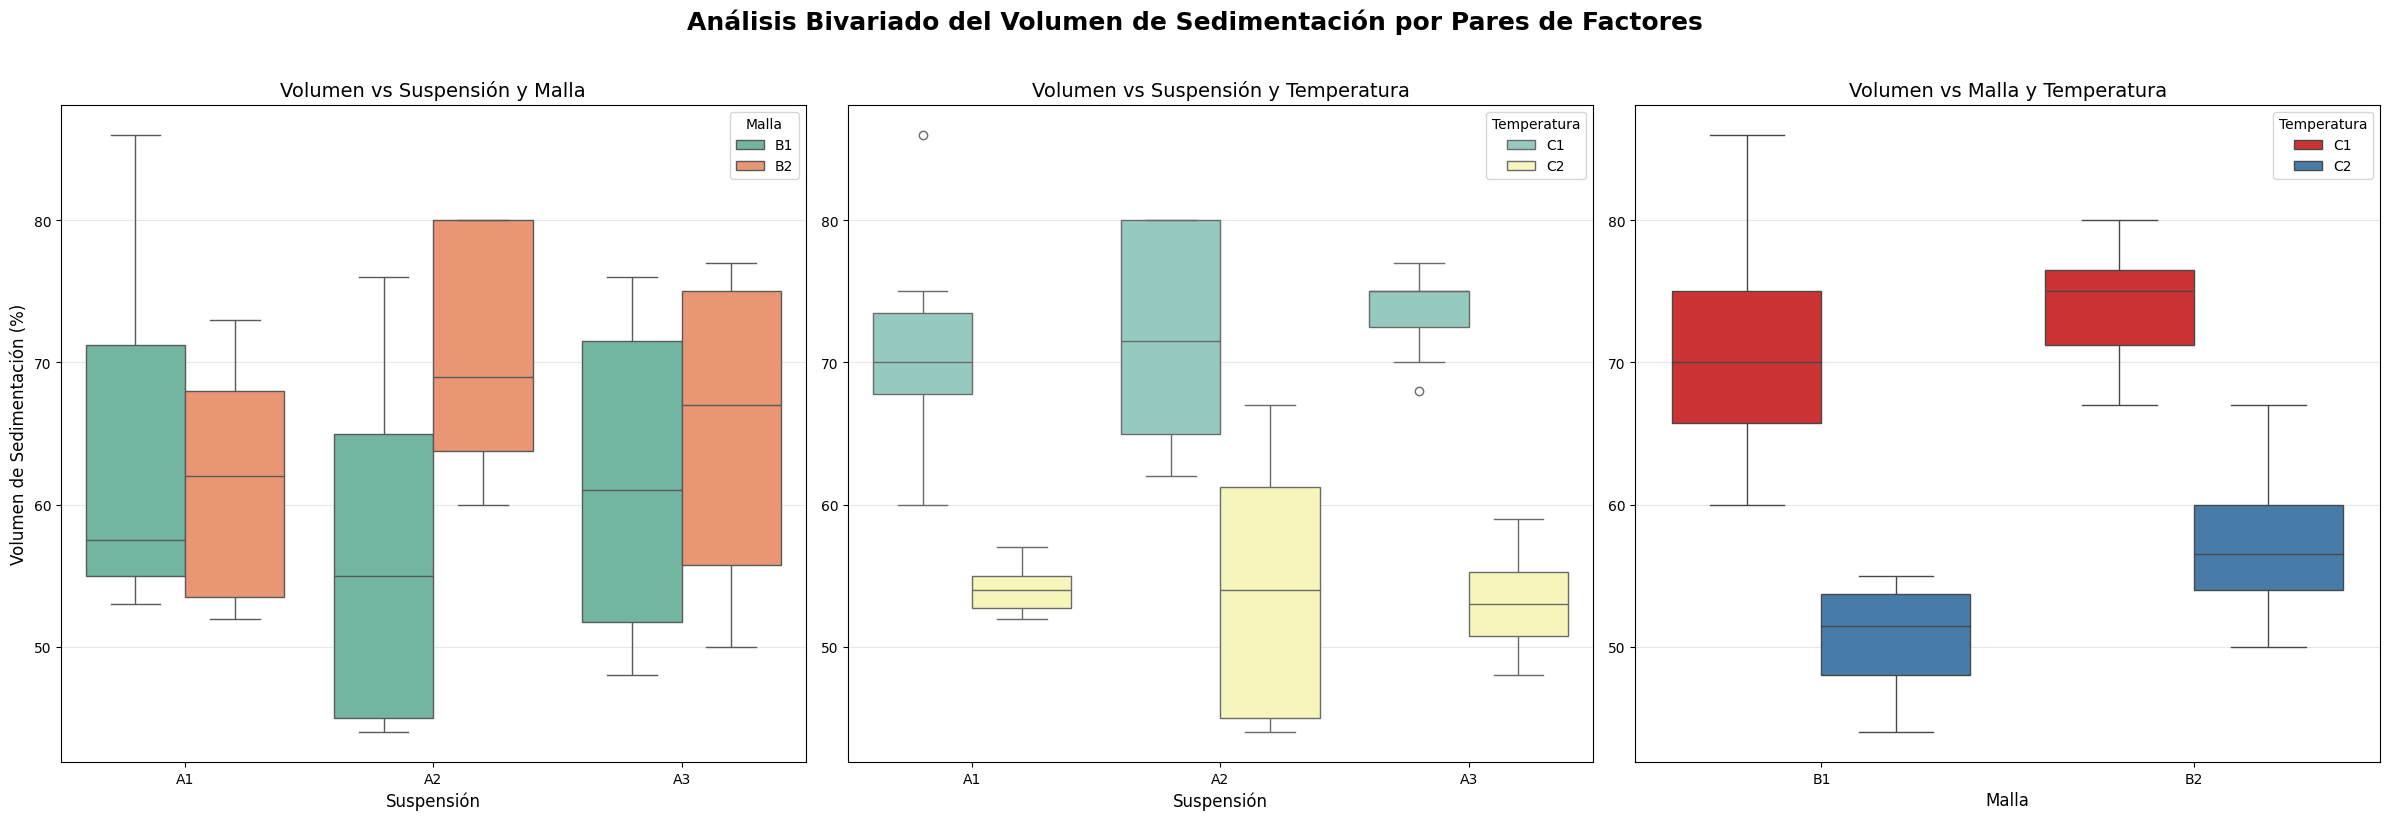

In [70]:
# @title **C. Diagramas de Caja Bivariados para el Diseño Factorial 3x2x2 - Mas colores**

import matplotlib.pyplot as plt
import seaborn as sns

# Crear figura con subplots
fig, axs = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Análisis Bivariado del Volumen de Sedimentación por Pares de Factores',
             fontsize=18, fontweight='bold', y=1.02)

# Primer subplot: Volumen vs Suspensión y Malla
sns.boxplot(x="Suspension", y="volumen", hue='Malla', data=D3F, ax=axs[0], palette='Set2')
axs[0].set_title('Volumen vs Suspensión y Malla', fontsize=14)
axs[0].set_xlabel('Suspensión', fontsize=12)
axs[0].set_ylabel('Volumen de Sedimentación (%)', fontsize=12)
axs[0].grid(axis='y', alpha=0.3)
axs[0].legend(title='Malla')

# Segundo subplot: Volumen vs Suspensión y Temperatura
sns.boxplot(x="Suspension", y="volumen", hue='Temperatura', data=D3F, ax=axs[1], palette='Set3')
axs[1].set_title('Volumen vs Suspensión y Temperatura', fontsize=14)
axs[1].set_xlabel('Suspensión', fontsize=12)
axs[1].set_ylabel('') # Remover label duplicado
axs[1].grid(axis='y', alpha=0.3)
axs[1].legend(title='Temperatura')

# Tercer subplot: Volumen vs Malla y Temperatura
sns.boxplot(x="Malla", y="volumen", hue='Temperatura', data=D3F, ax=axs[2], palette='Set1')
axs[2].set_title('Volumen vs Malla y Temperatura', fontsize=14)
axs[2].set_xlabel('Malla', fontsize=12)
axs[2].set_ylabel('') # Remover label duplicado
axs[2].grid(axis='y', alpha=0.3)
axs[2].legend(title='Temperatura')


plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Análisis de Varianza**




In [71]:
#@title **A. Media y desviación estandard**
print('f media y desviación típica para A')
D3F.groupby('Malla')['volumen'].agg(['mean', 'std'])

f media y desviación típica para A


,mean,std
Malla,,
B1,60.472222,11.450480
B2,65.638889,9.666297


In [72]:
#@title **B. Media y desviación estandard**
print('f media y desviación típica para A')
D3F.groupby('Suspension')['volumen'].agg(['mean', 'std'])

f media y desviación típica para A


,mean,std
Suspension,,
A1,62.458333,9.815601
A2,63.208333,12.140407
A3,63.500000,10.874781


In [73]:
#@title **C. Media y desviación estandard**
print('f media y desviación típica para A')
D3F.groupby('Temperatura')['volumen'].agg(['mean', 'std'])

f media y desviación típica para A


,mean,std
Temperatura,,
C1,72.250000,5.608030
C2,53.861111,5.737858


In [74]:
#@title **D. Media y desviación estandard por combinación de Factores**

print('f media y desviación típica para A')
D3F.groupby(['Suspension', 'Malla', 'Temperatura'])['volumen'].agg(['count','mean', 'std'])

f media y desviación típica para A


count       mean       std
Suspension Malla Temperatura                            
A1         B1    C1               6  72.666667  8.524475
                 C2               6  54.333333  1.032796
           B2    C1               6  69.333333  2.875181
                 C2               6  53.500000  1.974842
A2         B1    C1               6  66.833333  4.875107
                 C2               6  45.666667  1.861899
           B2    C1               6  77.166667  4.400758
                 C2               6  63.166667  3.544949
A3         B1    C1               6  72.166667  3.060501
                 C2               6  51.166667  2.041241
           B2    C1               6  75.333333  0.816497
                 C2               6  55.333333  3.011091

[⬆️ Volver al inicio](#inicio)

In [75]:
#@title **E. Análisis del Modelo Lineal General:$Acabado_{ijk} = (Velocidad)_i + (Profundidad)_j+(Velocidad*Profundidad)_{ij} + \epsilon_{ijk}$**

modeloD3F = smf.ols("volumen ~ C(Temperatura) * C(Suspension) * C(Malla)", data = D3F).fit()
print(modeloD3F.summary())

                            OLS Regression Results                            
Dep. Variable:                volumen   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     48.59
Date:                Tue, 16 Sep 2025   Prob (F-statistic):           1.04e-25
Time:                        15:42:46   Log-Likelihood:                -190.68
No. Observations:                  72   AIC:                             405.4
Df Residuals:                      60   BIC:                             432.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [76]:
#@title **F. Análisis de Varianza de las componentes del Modelo Tipo II**
#modeloD2F = ols("Acabado ~ C(Velocidad) + C(Profundidad)+C(Velocidad) * C(Profundidad)", data = D2F).fit()
modeloD3F = ols("volumen ~ C(Temperatura) * C(Suspension) * C(Malla)", data = D3F).fit()
anova_result = sm.stats.anova_lm(modeloD3F, typ=1)
print (anova_result)

                                         df       sum_sq      mean_sq  \
C(Temperatura)                          1.0  6086.722222  6086.722222   
C(Suspension)                           2.0    13.861111     6.930556   
C(Malla)                                1.0   480.500000   480.500000   
C(Temperatura):C(Suspension)            2.0    40.861111    20.430556   
C(Temperatura):C(Malla)                 1.0    56.888889    56.888889   
C(Suspension):C(Malla)                  2.0   788.250000   394.125000   
C(Temperatura):C(Suspension):C(Malla)   2.0    31.027778    15.513889   
Residual                               60.0   841.666667    14.027778   

                                                F        PR(>F)  
C(Temperatura)                         433.904950  3.745002e-29  
C(Suspension)                            0.494059  6.126048e-01  
C(Malla)                                34.253465  2.162425e-07  
C(Temperatura):C(Suspension)             1.456436  2.411861e-01  
C(Temperatur

[⬆️ Volver al inicio](#inicio)

In [78]:
#@title **G. Análisis de Varianza de las componentes del Modelo Tipo II**


pg.anova(
    data     = D3F,
    dv       = 'volumen',
    between  = ['Temperatura', 'Suspension', 'Malla'],
    detailed = True
).round(4)

,Source,SS,DF,MS,F,p-unc,np2
0,Temperatura,6086.7222,1.0,6086.7222,433.9050,0.0000,0.8785
1,Suspension,13.8611,2.0,6.9306,0.4941,0.6126,0.0162
2,Malla,480.5000,1.0,480.5000,34.2535,0.0000,0.3634
3,Temperatura * Suspension,40.8611,2.0,20.4306,1.4564,0.2412,0.0463
4,Temperatura * Malla,56.8889,1.0,56.8889,4.0554,0.0485,0.0633
5,Suspension * Malla,788.2500,2.0,394.1250,28.0960,0.0000,0.4836
6,Temperatura * Suspension * Malla,31.0278,2.0,15.5139,1.1059,0.3375,0.0356
7,Residual,841.6667,60.0,14.0278,NaN,NaN,NaN


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>

## **6. Interpretación del Análisis de Varianza (ANOVA)**

Basado en los resultados del ANOVA (mostrados en la tabla generada previamente), podemos interpretar la significancia estadística (usando los p-valores, `p-unc`) y el tamaño del efecto (usando la Eta Cuadrada Parcial, `np2`) de cada factor y sus interacciones en el volumen de sedimentación.

**Criterio de significancia:** Utilizamos un nivel de significancia ($\alpha$) de 0.05. Un p-valor menor que 0.05 indica que el efecto es estadísticamente significativo.

**Interpretación de los resultados:**

| Fuente                                | p-unc (Significancia) | np2 (Tamaño del Efecto) | Interpretación                                                                                                |
| :------------------------------------ | :-------------------- | :---------------------- | :------------------------------------------------------------------------------------------------------------ |
| **Temperatura**                       | 0.0000                | 0.8785                  | **Altamente Significativo (p < 0.05)** y con un **Tamaño del Efecto Muy Grande**. La temperatura tiene un impacto muy fuerte en el volumen de sedimentación. |
| **Suspension**                        | 0.6126                | 0.0162                  | **No Significativo (p > 0.05)** y con un **Tamaño del Efecto Pequeño**. No hay evidencia estadística de que la suspensión por sí sola tenga un efecto significativo. |
| **Malla**                             | 0.0000                | 0.3634                  | **Altamente Significativo (p < 0.05)** y con un **Tamaño del Efecto Grande**. La malla tiene un impacto considerable en el volumen de sedimentación. |
| **Temperatura * Suspension**          | 0.2412                | 0.0463                  | **No Significativo (p > 0.05)** y con un **Tamaño del Efecto Pequeño**. No hay evidencia estadística de una interacción significativa entre Temperatura y Suspensión. |
| **Temperatura * Malla**               | 0.0485                | 0.0633                  | **Significativo (p < 0.05)** y con un **Tamaño del Efecto Mediano**. Existe una interacción significativa entre Temperatura y Malla, aunque el tamaño del efecto es moderado. |
| **Suspension * Malla**                | 0.0000                | 0.4836                  | **Altamente Significativo (p < 0.05)** y con un **Tamaño del Efecto Grande**. Hay una interacción muy importante entre Suspensión y Malla, lo que significa que el efecto de uno depende del nivel del otro. |
| **Temperatura * Suspension * Malla**  | 0.3375                | 0.0356                  | **No Significativo (p > 0.05)** y con un **Tamaño del Efecto Pequeño**. No hay evidencia estadística de una interacción significativa de tercer orden. |

**Conclusión del ANOVA:**

Los factores **Temperatura**, **Malla** y la interacción **Suspension * Malla** tienen un efecto estadísticamente significativo en el volumen de sedimentación. La Temperatura y la interacción Suspensión * Malla muestran tamaños del efecto particularmente grandes. La interacción Temperatura * Malla también es significativa con un tamaño del efecto mediano. Los efectos principales de Suspensión y las otras interacciones no son estadísticamente significativos al nivel de 0.05.

Dado que hay interacciones significativas (especialmente Suspension * Malla), es importante examinar los gráficos de interacción y realizar comparaciones múltiples para entender mejor cómo estas combinaciones de factores afectan el volumen de sedimentación.

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Gráfico de interacciones entre los factores**




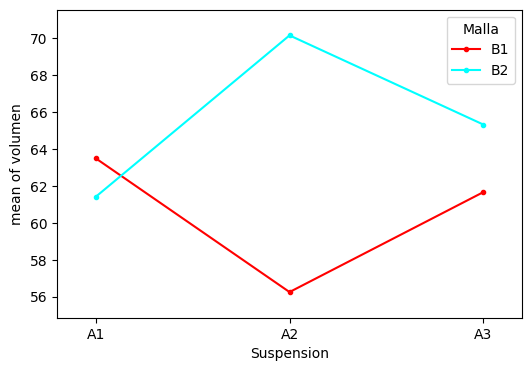

In [79]:
# @title **A Gráfico de interacciones A*B**
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = D3F.Suspension,
    trace    = D3F.Malla,
    response = D3F.volumen,
    ax       = ax,
)

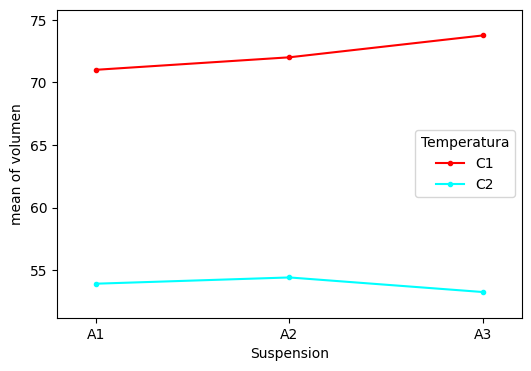

In [80]:
# @title **B. Gráfico de interacciones B*A**
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = D3F.Suspension,
    trace    = D3F.Temperatura,
    response = D3F.volumen,
    ax       = ax,
)

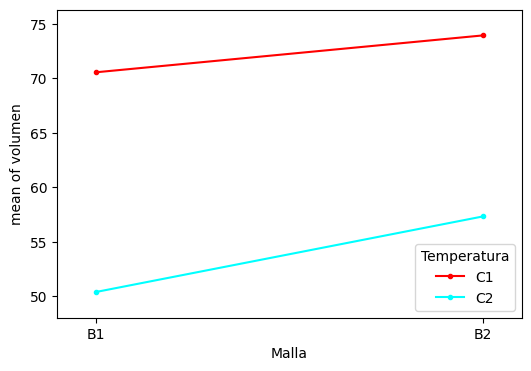

In [81]:
# @title **C. Gráfico de interacciones B*A**
fig, ax = plt.subplots(figsize=(6, 4))
fig = interaction_plot(
    x        = D3F.Malla,
    trace    = D3F.Temperatura,
    response = D3F.volumen,
    ax       = ax,
)

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Comparaciones Múltiples - HSD - Para las Formulaciones**


group1,group2,meandiff,p-adj,lower,upper,reject
A1,A2,0.75,0.9696,-6.8456,8.3456,False
A1,A3,1.0417,0.9423,-6.5539,8.6373,False
A2,A3,0.2917,0.9953,-7.3039,7.8873,False


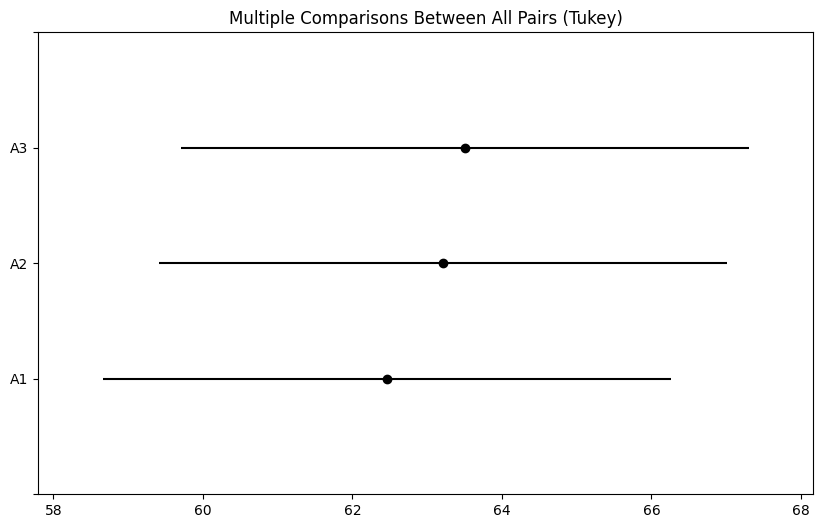

In [82]:
# @title **A. Comparaciones Múltiples: volumen VS Suspension**
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Suspension"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

group1,group2,meandiff,p-adj,lower,upper,reject
C1,C2,-18.3889,0.0,-21.0559,-15.7219,True


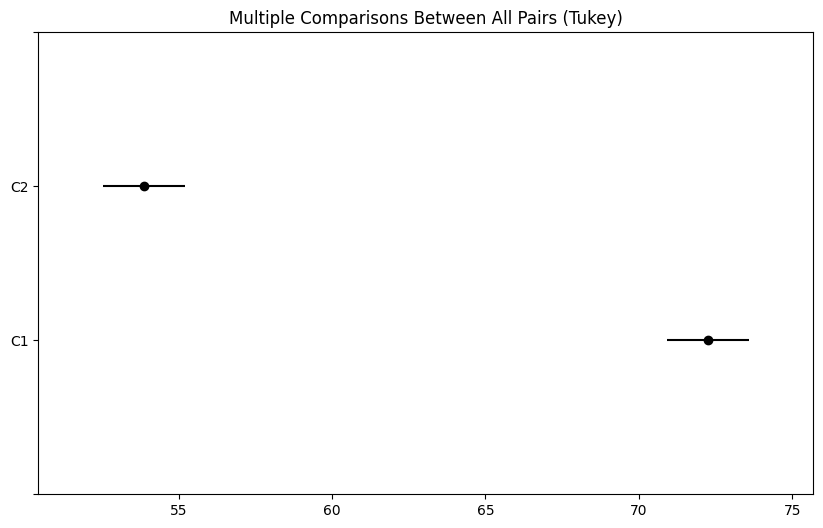

In [83]:
# @title **B. Comparaciones Múltiples: volumen VS Temperatura**
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Temperatura"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
B1,B2,5.1667,0.0423,0.1856,10.1478,True


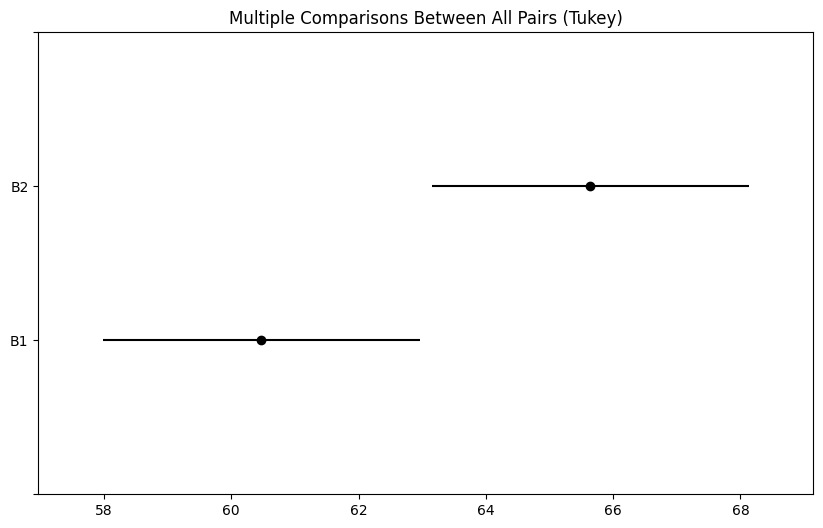

In [84]:
# @title **C. Comparaciones Múltiples: volumen VS Temperatura**
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Malla"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-375653820.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Malla", y="volumen", data=D3F, ax=ax1,


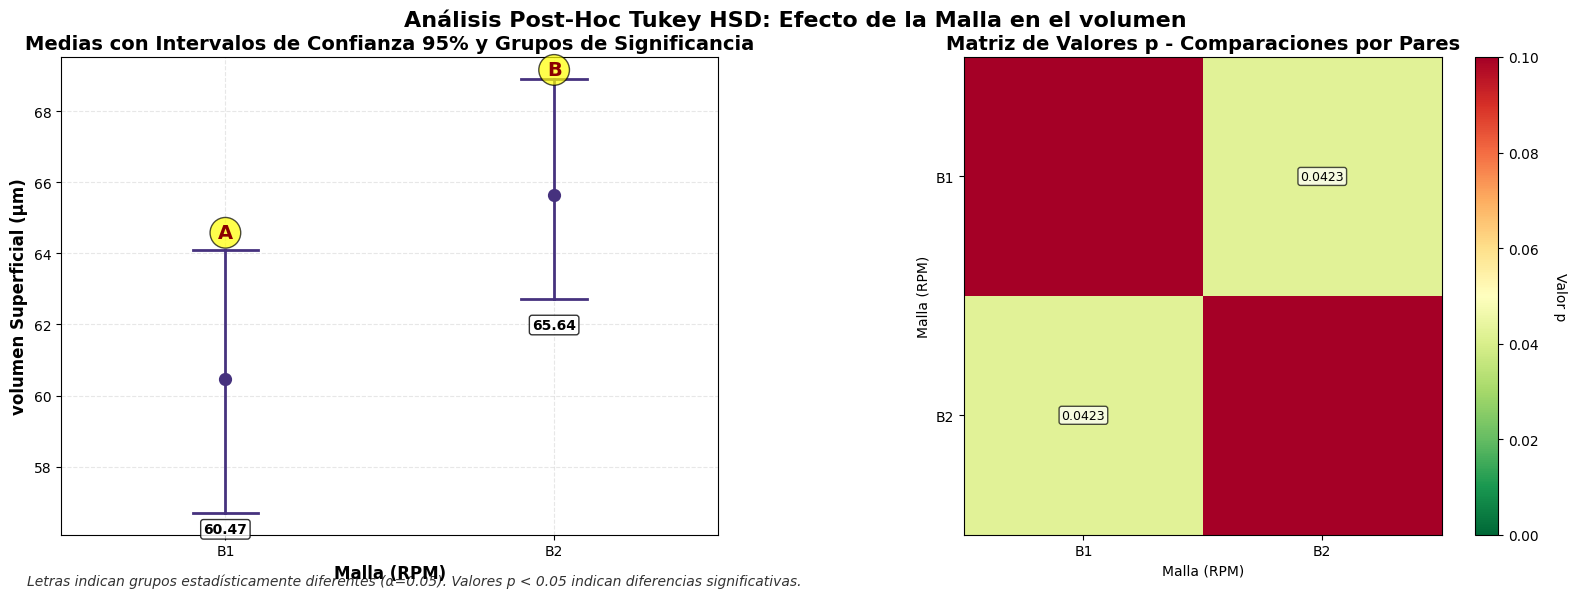


RESULTADOS DETALLADOS TUKEY HSD - Malla vs volumen
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    B1     B2   5.1667 0.0423 0.1856 10.1478   True
---------------------------------------------------

Resumen estadístico por grupo:
       count    mean     std  min  max
Malla                                 
B1        36  60.472  11.450   44   86
B2        36  65.639   9.666   50   80


In [85]:
# @title **D. Análisis Post-Hoc Tukey HSD para Malla - Mejorado**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# Calcular Tukey HSD
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Malla"],   # Groups
                          alpha=0.05)               # Significance level

# Obtener resumen de resultados
tukey_summary = tukey.summary()
tukey_table = pd.DataFrame(tukey_summary.data[1:], columns=tukey_summary.data[0])

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc Tukey HSD: Efecto de la Malla en el volumen',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
# Calcular estadísticas
medias = D3F.groupby("Malla")["volumen"].mean()
std_dev = D3F.groupby("Malla")["volumen"].std()
counts = D3F.groupby("Malla")["volumen"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Crear gráfico de puntos con intervalos de confianza
sns.pointplot(x="Malla", y="volumen", data=D3F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Añadir letras de grupos de significancia
formulacion_groups = {}
for i, group in enumerate(tukey.groupsunique):
    group_str = str(group)
    # Buscar la letra correspondiente en los resultados
    mask = (tukey_table['group1'] == group_str) | (tukey_table['group2'] == group_str)
    significant_groups = tukey_table[mask]

    # Asignar letra (simplificado - en la práctica se usaría una asignación adecuada)
    group_letter = chr(65 + i)  # A, B, C, ...
    formulacion_groups[group_str] = group_letter

    # Colocar texto encima de cada media
    y_pos = medias[group] + ci[group] + 0.1
    ax1.text(i, y_pos, group_letter, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Malla (RPM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('volumen Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (Malla, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[Malla] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de Tukey HSD
# =========================================================================
# Crear matriz de valores p
groups_unique = tukey.groupsunique
p_value_matrix = np.ones((len(groups_unique), len(groups_unique)))

for result in tukey._results_table.data[1:]:
    group1_idx = np.where(groups_unique == result[0])[0][0]
    group2_idx = np.where(groups_unique == result[1])[0][0]
    p_value = result[3]
    p_value_matrix[group1_idx, group2_idx] = p_value
    p_value_matrix[group2_idx, group1_idx] = p_value

# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(groups_unique)))
ax2.set_yticks(np.arange(len(groups_unique)))
ax2.set_xticklabels([str(g) for g in groups_unique])
ax2.set_yticklabels([str(g) for g in groups_unique])
ax2.set_xlabel('Malla (RPM)')
ax2.set_ylabel('Malla (RPM)')

# Añadir valores en las celdas
for i in range(len(groups_unique)):
    for j in range(len(groups_unique)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         'Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS TUKEY HSD - Malla vs volumen")
print("="*70)
print(tukey)
print("\nResumen estadístico por grupo:")
print(D3F.groupby("Malla")["volumen"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-3273668219.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Suspension", y="volumen", data=D3F, ax=ax1,


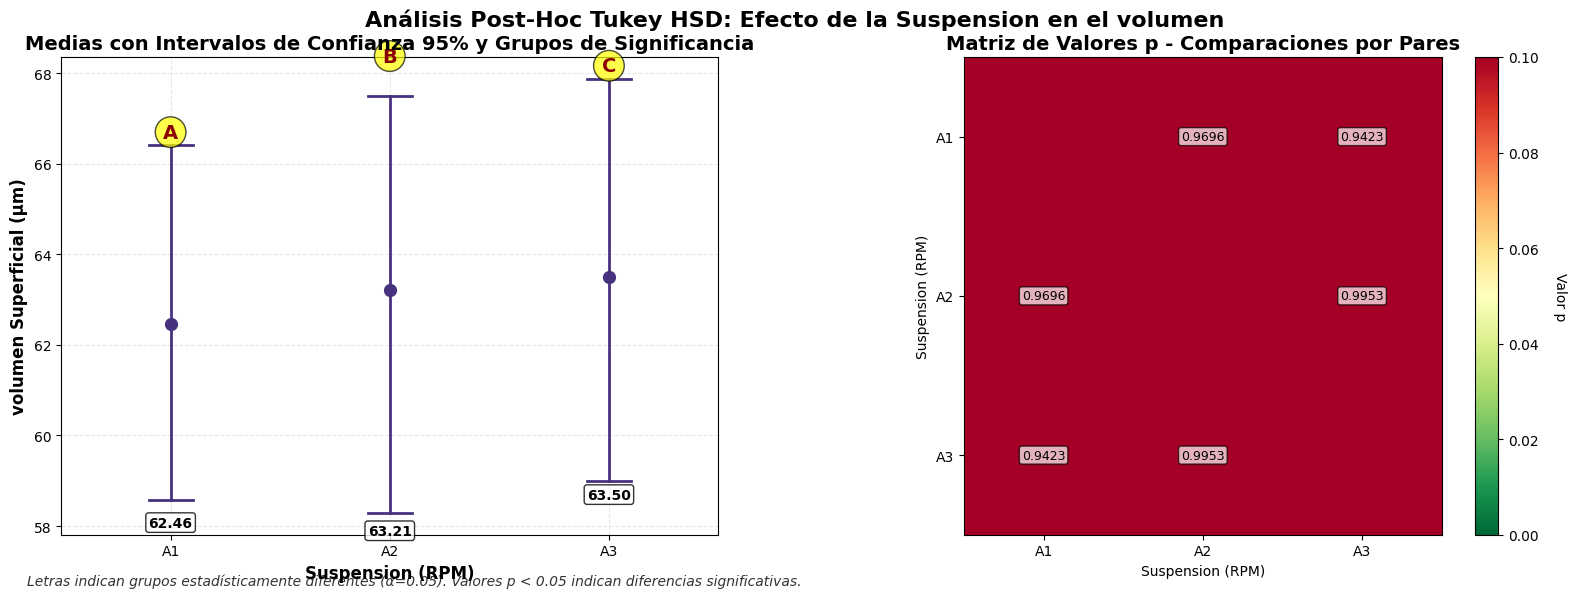


RESULTADOS DETALLADOS TUKEY HSD - Suspension vs volumen
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    A1     A2     0.75 0.9696 -6.8456 8.3456  False
    A1     A3   1.0417 0.9423 -6.5539 8.6373  False
    A2     A3   0.2917 0.9953 -7.3039 7.8873  False
---------------------------------------------------

Resumen estadístico por grupo:
            count    mean     std  min  max
Suspension                                 
A1             24  62.458   9.816   52   86
A2             24  63.208  12.140   44   80
A3             24  63.500  10.875   48   77


In [86]:
# @title **E. Análisis Post-Hoc Tukey HSD para Suspension - Mejorado**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# Calcular Tukey HSD
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Suspension"],   # Groups
                          alpha=0.05)               # Significance level

# Obtener resumen de resultados
tukey_summary = tukey.summary()
tukey_table = pd.DataFrame(tukey_summary.data[1:], columns=tukey_summary.data[0])

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc Tukey HSD: Efecto de la Suspension en el volumen',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
# Calcular estadísticas
medias = D3F.groupby("Suspension")["volumen"].mean()
std_dev = D3F.groupby("Suspension")["volumen"].std()
counts = D3F.groupby("Suspension")["volumen"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Crear gráfico de puntos con intervalos de confianza
sns.pointplot(x="Suspension", y="volumen", data=D3F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Añadir letras de grupos de significancia
formulacion_groups = {}
for i, group in enumerate(tukey.groupsunique):
    group_str = str(group)
    # Buscar la letra correspondiente en los resultados
    mask = (tukey_table['group1'] == group_str) | (tukey_table['group2'] == group_str)
    significant_groups = tukey_table[mask]

    # Asignar letra (simplificado - en la práctica se usaría una asignación adecuada)
    group_letter = chr(65 + i)  # A, B, C, ...
    formulacion_groups[group_str] = group_letter

    # Colocar texto encima de cada media
    y_pos = medias[group] + ci[group] + 0.1
    ax1.text(i, y_pos, group_letter, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Suspension (RPM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('volumen Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (Suspension, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[Suspension] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de Tukey HSD
# =========================================================================
# Crear matriz de valores p
groups_unique = tukey.groupsunique
p_value_matrix = np.ones((len(groups_unique), len(groups_unique)))

for result in tukey._results_table.data[1:]:
    group1_idx = np.where(groups_unique == result[0])[0][0]
    group2_idx = np.where(groups_unique == result[1])[0][0]
    p_value = result[3]
    p_value_matrix[group1_idx, group2_idx] = p_value
    p_value_matrix[group2_idx, group1_idx] = p_value

# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(groups_unique)))
ax2.set_yticks(np.arange(len(groups_unique)))
ax2.set_xticklabels([str(g) for g in groups_unique])
ax2.set_yticklabels([str(g) for g in groups_unique])
ax2.set_xlabel('Suspension (RPM)')
ax2.set_ylabel('Suspension (RPM)')

# Añadir valores en las celdas
for i in range(len(groups_unique)):
    for j in range(len(groups_unique)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         'Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS TUKEY HSD - Suspension vs volumen")
print("="*70)
print(tukey)
print("\nResumen estadístico por grupo:")
print(D3F.groupby("Suspension")["volumen"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-2293963794.py:37: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="Temperatura", y="volumen", data=D3F, ax=ax1,


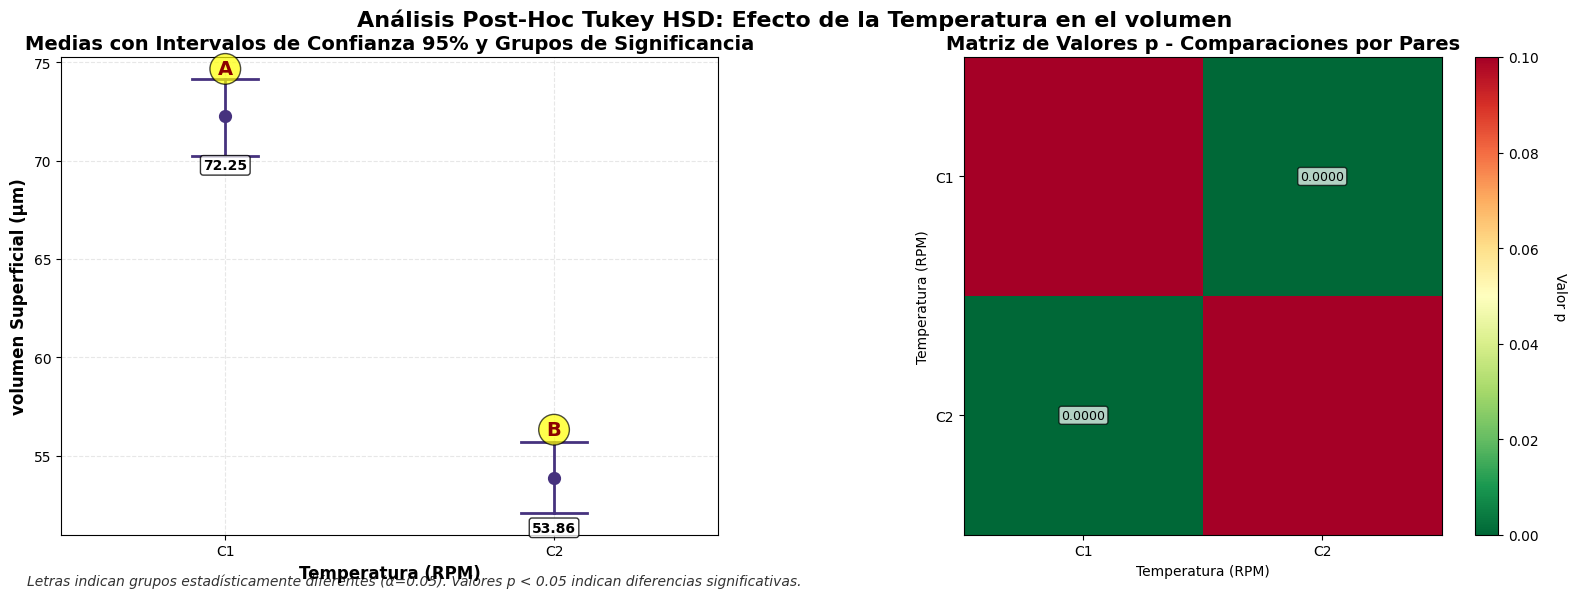


RESULTADOS DETALLADOS TUKEY HSD - Temperatura vs volumen
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
    C1     C2 -18.3889   0.0 -21.0559 -15.7219   True
-----------------------------------------------------

Resumen estadístico por grupo:
             count    mean    std  min  max
Temperatura                                
C1              36  72.250  5.608   60   86
C2              36  53.861  5.738   44   67


In [87]:
# @title **F. Análisis Post-Hoc Tukey HSD para Temperatura - Mejorado**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# Calcular Tukey HSD
tukey = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                          groups=D3F["Temperatura"],   # Groups
                          alpha=0.05)               # Significance level

# Obtener resumen de resultados
tukey_summary = tukey.summary()
tukey_table = pd.DataFrame(tukey_summary.data[1:], columns=tukey_summary.data[0])

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Post-Hoc Tukey HSD: Efecto de la Temperatura en el volumen',
             fontsize=16, fontweight='bold', y=0.98)

# =========================================================================
# Gráfico de medias con intervalos de confianza y grupos de significancia
# =========================================================================
# Calcular estadísticas
medias = D3F.groupby("Temperatura")["volumen"].mean()
std_dev = D3F.groupby("Temperatura")["volumen"].std()
counts = D3F.groupby("Temperatura")["volumen"].count()
ci = 1.96 * (std_dev / np.sqrt(counts))  # 95% CI

# Crear gráfico de puntos con intervalos de confianza
sns.pointplot(x="Temperatura", y="volumen", data=D3F, ax=ax1,
              errorbar=('ci', 95), capsize=0.2, join=False,
              markers='o', linestyle='-', linewidth=2, markersize=8)

# Añadir letras de grupos de significancia
formulacion_groups = {}
for i, group in enumerate(tukey.groupsunique):
    group_str = str(group)
    # Buscar la letra correspondiente en los resultados
    mask = (tukey_table['group1'] == group_str) | (tukey_table['group2'] == group_str)
    significant_groups = tukey_table[mask]

    # Asignar letra (simplificado - en la práctica se usaría una asignación adecuada)
    group_letter = chr(65 + i)  # A, B, C, ...
    formulacion_groups[group_str] = group_letter

    # Colocar texto encima de cada media
    y_pos = medias[group] + ci[group] + 0.1
    ax1.text(i, y_pos, group_letter, ha='center', va='bottom',
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="circle,pad=0.3", facecolor='yellow', alpha=0.7))

# Mejorar el primer gráfico
ax1.set_title('Medias con Intervalos de Confianza 95% y Grupos de Significancia',
              fontsize=14, fontweight='semibold')
ax1.set_xlabel('Temperatura (RPM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('volumen Superficial (μm)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Añadir valores de media en las barras
for i, (Temperatura, media) in enumerate(medias.items()):
    ax1.text(i, media - ci[Temperatura] - 0.3, f'{media:.2f}',
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# =========================================================================
# Heatmap de valores p de Tukey HSD
# =========================================================================
# Crear matriz de valores p
groups_unique = tukey.groupsunique
p_value_matrix = np.ones((len(groups_unique), len(groups_unique)))

for result in tukey._results_table.data[1:]:
    group1_idx = np.where(groups_unique == result[0])[0][0]
    group2_idx = np.where(groups_unique == result[1])[0][0]
    p_value = result[3]
    p_value_matrix[group1_idx, group2_idx] = p_value
    p_value_matrix[group2_idx, group1_idx] = p_value

# Crear heatmap
im = ax2.imshow(p_value_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax2.set_title('Matriz de Valores p - Comparaciones por Pares',
              fontsize=14, fontweight='semibold')
ax2.set_xticks(np.arange(len(groups_unique)))
ax2.set_yticks(np.arange(len(groups_unique)))
ax2.set_xticklabels([str(g) for g in groups_unique])
ax2.set_yticklabels([str(g) for g in groups_unique])
ax2.set_xlabel('Temperatura (RPM)')
ax2.set_ylabel('Temperatura (RPM)')

# Añadir valores en las celdas
for i in range(len(groups_unique)):
    for j in range(len(groups_unique)):
        if i != j:
            text = ax2.text(j, i, f'{p_value_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=9,
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Barra de color
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valor p', rotation=270, labelpad=20)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.3)

# Añadir leyenda informativa
fig.text(0.02, 0.02,
         'Letras indican grupos estadísticamente diferentes (α=0.05). '
         'Valores p < 0.05 indican diferencias significativas.',
         fontsize=10, style='italic', alpha=0.8)

plt.show()

# =========================================================================
# Imprimir resultados detallados
# =========================================================================
print("\n" + "="*70)
print("RESULTADOS DETALLADOS TUKEY HSD - Temperatura vs volumen")
print("="*70)
print(tukey)
print("\nResumen estadístico por grupo:")
print(D3F.groupby("Temperatura")["volumen"].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

[⬆️ Volver al inicio](#inicio)

Group names from summary: ['C1']
Unique groups in data: ['C1' 'C2']


/tmp/ipython-input-2986424543.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Temperatura", y="volumen", data=D3F,


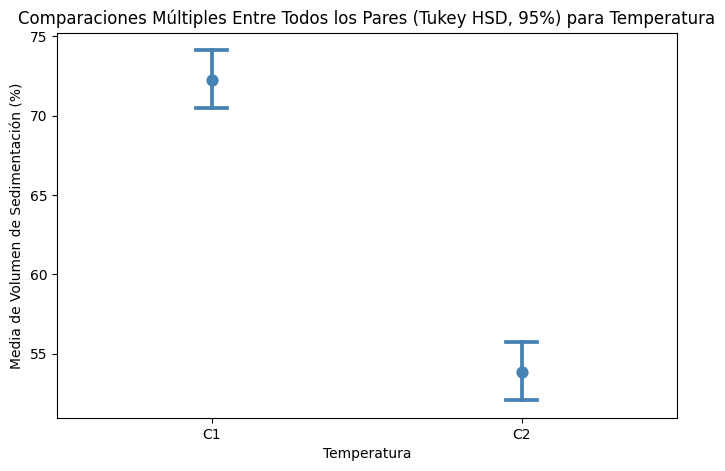

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
    C1     C2 -18.3889   0.0 -21.0559 -15.7219   True
-----------------------------------------------------


In [88]:
# @title **G. Gráfico de Comparaciones Múltiples (Tukey HSD) para Temperatura**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Calcular Tukey HSD para Temperatura
tukey_temperatura = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                                      groups=D3F["Temperatura"],   # Groups
                                      alpha=0.05)          # Significance level

# Obtener el resumen de resultados de Tukey HSD
tukey_summary = tukey_temperatura.summary()

# Extract the group names from the summary table
# Check the number of rows in the summary data
if len(tukey_summary.data) > 1:
    # The group names are in the first column of the table
    # We need to skip the header row (index 0)
    # Handle both string and integer group names
    group_names_summary = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:]]
else:
    # If there are no data rows, group_names_summary will be an empty list
    group_names_summary = []

# Initialize temperatura_groups before the if block
temperatura_groups = {}

# Create a dictionary to map Temperatura to group name from the summary
# The group names are assigned based on the order of unique groups in the tukey object
# Ensure group_names_summary is not empty before zipping
if group_names_summary:
    # Ensure the number of group names matches the number of unique groups in tukey object
    if len(group_names_summary) == len(tukey_temperatura.groupsunique):
        temperatura_groups = dict(zip([str(group) for group in tukey_temperatura.groupsunique], group_names_summary))
    else:
        # Handle cases where the number of groups in summary doesn't match unique groups
        print("Warning: Number of groups in Tukey summary does not match unique groups in data.")
        print("Group names from summary:", group_names_summary)
        print("Unique groups in data:", tukey_temperatura.groupsunique)


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Temperatura", y="volumen", data=D3F,
                   errorbar=('ci', 95), capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples Entre Todos los Pares (Tukey HSD, 95%) para Temperatura")
plt.ylabel("Media de Volumen de Sedimentación (%)")
plt.xlabel("Temperatura")

# Añadir letters encima de cada media solo si hay grupos de significancia
if temperatura_groups:
    medias = D3F.groupby("Temperatura")["volumen"].mean()
    for i, temp in enumerate(medias.index):
        # Find the corresponding group name for the Temperatura
        group_name = temperatura_groups.get(str(temp), '') # Use .get() with a default value in case a Temperatura is not in the tukey results

        # Only add text if a group name was found
        if group_name:
            plt.text(i, medias[temp] + 0.5, group_name,
                     ha='center', va='bottom', fontsize=12, color="black")

plt.show()

print(tukey_temperatura)

[⬆️ Volver al inicio](#inicio)

/tmp/ipython-input-1408689903.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Suspension", y="volumen", data=D3F,


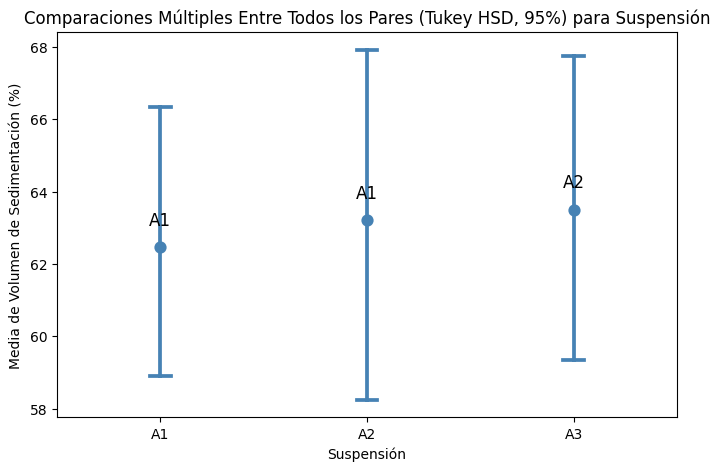

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    A1     A2     0.75 0.9696 -6.8456 8.3456  False
    A1     A3   1.0417 0.9423 -6.5539 8.6373  False
    A2     A3   0.2917 0.9953 -7.3039 7.8873  False
---------------------------------------------------


In [89]:
# @title **H. Gráfico de Comparaciones Múltiples (Tukey HSD) para Suspensión**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Calcular Tukey HSD para Suspension
tukey_suspension = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                                      groups=D3F["Suspension"],   # Groups
                                      alpha=0.05)          # Significance level

# Obtener el resumen de resultados de Tukey HSD
tukey_summary = tukey_suspension.summary()

# Extract the group names from the summary table
# Check the number of rows in the summary data
if len(tukey_summary.data) > 1:
    # The group names are in the first column of the table
    # We need to skip the header row (index 0)
    # Extract all data rows from index 1 onwards
    group_names_summary = [str(row[0]).strip() if isinstance(row[0], str) else str(row[0]) for row in tukey_summary.data[1:]]
else:
    # If there are no data rows, group_names_summary will be an empty list
    group_names_summary = []

# Initialize suspension_groups before the if block
suspension_groups = {}

# Create a dictionary to map Suspension to group name from the summary
# The group names are assigned based on the order of unique groups in the tukey object
# Ensure group_names_summary is not empty before zipping
if group_names_summary:
    # Ensure the number of group names matches the number of unique groups in tukey object
    if len(group_names_summary) == len(tukey_suspension.groupsunique):
        suspension_groups = dict(zip([str(group) for group in tukey_suspension.groupsunique], group_names_summary))
    else:
        # Handle cases where the number of groups in summary doesn't match unique groups
        print("Warning: Number of groups in Tukey summary does not match unique groups in data.")
        print("Group names from summary:", group_names_summary)
        print("Unique groups in data:", tukey_suspension.groupsunique)


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Suspension", y="volumen", data=D3F,
                   errorbar=('ci', 95), capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples Entre Todos los Pares (Tukey HSD, 95%) para Suspensión")
plt.ylabel("Media de Volumen de Sedimentación (%)")
plt.xlabel("Suspensión")

# Añadir letters encima de cada media solo si hay grupos de significancia
if suspension_groups:
    medias = D3F.groupby("Suspension")["volumen"].mean()
    for i, temp in enumerate(medias.index):
        # Find the corresponding group name for the Suspension
        group_name = suspension_groups.get(str(temp), '') # Use .get() with a default value in case a Suspension is not in the tukey results

        # Only add text if a group name was found
        if group_name:
            plt.text(i, medias[temp] + 0.5, group_name,
                     ha='center', va='bottom', fontsize=12, color="black")

plt.show()

print(tukey_suspension)

/tmp/ipython-input-2215426598.py:49: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Malla", y="volumen", data=D3F,


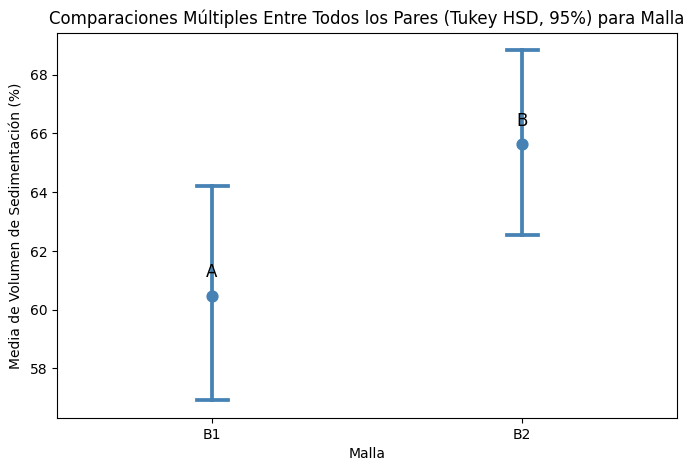

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    B1     B2   5.1667 0.0423 0.1856 10.1478   True
---------------------------------------------------


In [90]:
# @title **I. Gráfico de Comparaciones Múltiples (Tukey HSD) para Malla**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Calcular Tukey HSD para Malla
tukey_malla = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                                      groups=D3F["Malla"],   # Groups
                                      alpha=0.05)          # Significance level

# Obtener el resumen de resultados de Tukey HSD
tukey_summary = tukey_malla.summary()

# Initialize malla_groups dictionary
malla_groups = {}
unique_groups = tukey_malla.groupsunique
first_letter = 'A'

# Assign group letters based on significance
# For a factor with only two levels, there's only one comparison
if len(unique_groups) == 2:
    # Check the reject status of the single comparison
    if tukey_summary.data[1][-1]: # data[1] is the first result row, [-1] is the reject column
        # If significant, assign different letters
        malla_groups[str(unique_groups[0])] = first_letter
        malla_groups[str(unique_groups[1])] = chr(ord(first_letter) + 1)
    else:
        # If not significant, assign the same letter
        malla_groups[str(unique_groups[0])] = first_letter
        malla_groups[str(unique_groups[1])] = first_letter
else:
    # For factors with more than two levels, a more complex logic would be needed
    # For now, if there are no significant differences, assign the same letter
    if not any(row[-1] for row in tukey_summary.data[1:]):
         for group in unique_groups:
            malla_groups[str(group)] = first_letter
    else:
         # This part would need a proper algorithm for multiple comparisons
         print("Warning: Complex group letter assignment needed for more than 2 groups with significant differences.")
         # For simplicity in this specific case (Malla has only 2 levels), this else won't be reached.
         # For Suspension (3 levels, no significant differences), the 'not any' block above handles it.
         pass # Implement a proper letter assignment algorithm here if needed


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Malla", y="volumen", data=D3F,
                   errorbar=('ci', 95), capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples Entre Todos los Pares (Tukey HSD, 95%) para Malla")
plt.ylabel("Media de Volumen de Sedimentación (%)")
plt.xlabel("Malla")

# Añadir letters encima de cada media solo if malla_groups is not empty
if malla_groups:
    medias = D3F.groupby("Malla")["volumen"].mean()
    for i, temp in enumerate(medias.index):
        # Find the corresponding group name for the Malla
        group_name = malla_groups.get(str(temp), '')

        # Only add text if a group name was found
        if group_name:
            plt.text(i, medias[temp] + 0.5, group_name,
                     ha='center', va='bottom', fontsize=12, color="black")

plt.show()

print(tukey_malla)

[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD**



## 🔹 **A. Diferencia clave entre** _**Tukey HSD**_ y **Fisher LSD**

* **Tukey HSD** es más conservador: controla mejor el error tipo I cuando se hacen muchas comparaciones.
* **Fisher LSD** es más **liberal**: permite detectar más diferencias, pero con mayor riesgo de falsos positivos.
* En la práctica: **los grupos homogéneos con LSD suelen ser más pequeños**, porque LSD declara más pares como significativamente distintos.

---

## 🔹 **B. Pasos para adaptar el gráfico al método LSD**

1. Se calcula la **diferencia mínima significativa (LSD)** a partir del ANOVA:

$$
LSD = t_{\alpha/2, df_{error}} \cdot \sqrt{2 \cdot \frac{MS_{error}}{n}}
$$

donde:

* $t_{\alpha/2, df_{error}}$ es el valor crítico de la t de Student.
* $MS_{error}$ es el cuadrado medio del error del ANOVA.
* $n$ es el tamaño de muestra por grupo (aquí, 5).

2. Se comparan todas las diferencias de medias contra ese **LSD crítico**.
3. Se forman los **grupos homogéneos LSD** (pueden diferir de los que dio Tukey).


[⬆️ Volver al inicio](#inicio)

In [92]:
# @title **C. Cálculo del HSD Teórico para Suspensión en D3F**

import scipy.stats as stats
import numpy as np

# Parámetros para el factor Suspension en D3F
alpha = 0.05
# Número de grupos para el factor Suspension
k_suspension = len(D3F['Suspension'].unique())
# Grados de libertad del error y MSE del modelo ANOVA completo (modeloD3F)
df_error = modeloD3F.df_resid
mse = modeloD3F.mse_resid

# Tamaño de muestra por grupo para el factor Suspension (asumimos balanceado o usamos el promedio)
n_suspension = D3F.groupby('Suspension')['volumen'].count().mean()


# Calcular el valor crítico del rango studentizado para Suspension
q_critical_suspension = stats.studentized_range.ppf(1 - alpha, k_suspension, df_error)
HSD_suspension = q_critical_suspension * np.sqrt(mse / n_suspension)

print(f'{"="*40}')
print(f'{">>> HSD Teórico para el factor Suspension <<<":^40}')
print(f'{"="*40}')
print(f"Parámetros:")
print(f"- Número de grupos (k): {k_suspension}")
print(f"- Grados de libertad error: {df_error}")
print(f"- MSE del modelo: {mse:.4f}")
print(f"- Tamaño muestral promedio por grupo (n): {n_suspension:.2f}")
print(f"- Nivel de significancia (α): {alpha}")
print()
print(f"Valor crítico del rango studentizado (α={alpha}, k={k_suspension}, df={df_error}): {q_critical_suspension:.4f}")
print(f"HSD teórico para Suspension: {HSD_suspension:.4f}")

>>> HSD Teórico para el factor Suspension <<<
Parámetros:
- Número de grupos (k): 3
- Grados de libertad error: 60.0
- MSE del modelo: 14.0278
- Tamaño muestral promedio por grupo (n): 24.00
- Nivel de significancia (α): 0.05

Valor crítico del rango studentizado (α=0.05, k=3, df=60.0): 3.3987
HSD teórico para Suspension: 2.5983


[⬆️ Volver al inicio](#inicio)

No significant differences found based on Tukey HSD. All groups assigned letter 'A'.


/tmp/ipython-input-2741855582.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="Suspension", y="volumen", data=D3F,


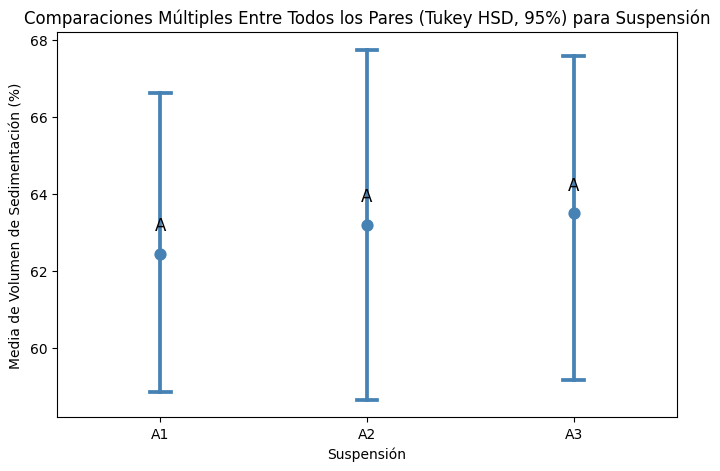

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    A1     A2     0.75 0.9696 -6.8456 8.3456  False
    A1     A3   1.0417 0.9423 -6.5539 8.6373  False
    A2     A3   0.2917 0.9953 -7.3039 7.8873  False
---------------------------------------------------


In [93]:
# @title **Gráfico de Comparaciones Múltiples (Tukey HSD) para Suspensión en D3F**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Calcular Tukey HSD para Suspension
tukey_suspension = pairwise_tukeyhsd(endog=D3F["volumen"],     # Data
                                     groups=D3F["Suspension"],   # Groups
                                     alpha=0.05)          # Significance level

# Obtener el resumen de resultados de Tukey HSD
tukey_summary = tukey_suspension.summary()

# Extract the results data (skipping header)
results_data = tukey_summary.data[1:]

# Initialize suspension_groups dictionary
suspension_groups = {}

# Check if any pairs are significantly different
if any(row[-1] for row in results_data): # Check the last element (reject column)
    # If there are significant differences, extract group names and rejection status
    # A more sophisticated algorithm is needed here for proper letter assignment with > 2 groups
    # For simplicity and demonstration, we'll just indicate if there are significant differences
    print("Significant differences found based on Tukey HSD.")
    print(tukey_suspension) # Print summary for manual interpretation of groups

    # A basic approach for letter assignment (works well for 2 groups, less so for more complex cases)
    # This part would need a proper algorithm for letter grouping based on pairwise comparisons
    # For now, we will skip adding letters if complex grouping is needed.
    print("Automatic group letter assignment for > 2 groups with significant differences is complex.")
    print("Please refer to the Tukey HSD summary above for significant pairs.")

else:
    # If no significant differences, assign the same letter to all groups
    unique_groups = tukey_suspension.groupsunique
    if len(unique_groups) > 0:
        first_letter = 'A'
        for group in unique_groups:
            suspension_groups[str(group)] = first_letter
        print("No significant differences found based on Tukey HSD. All groups assigned letter 'A'.")


# Gráfico de medias con intervalos de confianza de Tukey
plt.figure(figsize=(8, 5))
ax = sns.pointplot(x="Suspension", y="volumen", data=D3F,
                   errorbar=('ci', 95), capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples Entre Todos los Pares (Tukey HSD, 95%) para Suspensión")
plt.ylabel("Media de Volumen de Sedimentación (%)")
plt.xlabel("Suspensión")

# Añadir letters encima de cada media solo if suspension_groups is not empty
if suspension_groups: # Only add letters if suspension_groups was populated
    medias = D3F.groupby("Suspension")["volumen"].mean()
    for i, temp in enumerate(medias.index):
        # Find the corresponding group name for the Suspension
        group_name = suspension_groups.get(str(temp), '')

        # Only add text if a group name was found
        if group_name:
            plt.text(i, medias[temp] + 0.5, group_name,
                     ha='center', va='bottom', fontsize=12, color="black")
# Remove the redundant elif block here
# elif any(row[-1] for row in results_data):
#      print("Skipping automatic letter assignment due to complex grouping.")


plt.show()

print(tukey_suspension)

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Comparaciones Múltiples: LSD Vs HSD**




In [94]:
# @title **A. Comparaciones Múltiples: Cálculo de LSD y HSD Teóricos para Suspensión**
import numpy as np
import scipy.stats as stats
# Assuming modeloD3F is available from a previous cell execution

# Parámetros comunes del modelo ANOVA (modeloD3F)
alpha = 0.05
# Grados de libertad del error y MSE del modelo ANOVA completo (modeloD3F)
df_error = modeloD3F.df_resid
mse = modeloD3F.mse_resid

# Parámetros para el factor Suspension en D3F
k_suspension = len(D3F['Suspension'].unique())  # Número de grupos para el factor Suspension
n_suspension = D3F.groupby('Suspension')['volumen'].count().mean()  # Tamaño de muestra promedio por grupo


print("=" * 60)
print("CÁLCULO DE LSD Y HSD TEÓRICOS - SUSPENSION")
print("=" * 60)
print(f"Parámetros del modelo ANOVA:")
print(f"- Grados de libertad error: {df_error}")
print(f"- MSE: {mse:.4f}")
print()
print(f"Parámetros del factor Suspension:")
print(f"- Número de grupos (k): {k_suspension}")
print(f"- Tamaño muestral promedio (n): {n_suspension:.2f}")
print(f"- Nivel de significancia (α): {alpha}")
print()

# =========================================================================
# CÁLCULO DE LSD (Least Significant Difference) Teórico
# =========================================================================
t_critical_LSD = stats.t.ppf(1 - alpha / 2, df_error)
LSD_suspension = t_critical_LSD * np.sqrt(2 * mse / n_suspension)

print("CÁLCULO LSD TEÓRICO")
print("-" * 40)
print(f"Valor crítico t (α/2={alpha/2:.3f}, df={df_error}): {t_critical_LSD:.4f}")
print(f"LSD teórico para Suspension: {LSD_suspension:.4f}")
print()

# =========================================================================
# CÁLCULO DE HSD (Honestly Significant Difference) Teórico
# =========================================================================
q_critical_HSD = stats.studentized_range.ppf(1 - alpha, k_suspension, df_error)
HSD_suspension = q_critical_HSD * np.sqrt(mse / n_suspension)

print("CÁLCULO HSD TEÓRICO (Tukey)")
print("-" * 40)
print(f"Rango studentizado (α={alpha}, k={k_suspension}, df={df_error}): {q_critical_HSD:.4f}")
print(f"HSD teórico para Suspension: {HSD_suspension:.4f}")
print()

# =========================================================================
# COMPARACIÓN DE LSD y HSD
# =========================================================================
print("COMPARACIÓN LSD vs HSD")
print("-" * 40)
print(f"Diferencia |LSD - HSD|: {abs(LSD_suspension - HSD_suspension):.4f}")
print(f"LSD es más {'conservador' if LSD_suspension < HSD_suspension else 'liberal'} que HSD")
print(f"Ratio LSD/HSD: {LSD_suspension/HSD_suspension:.3f}")

CÁLCULO DE LSD Y HSD TEÓRICOS - SUSPENSION
Parámetros del modelo ANOVA:
- Grados de libertad error: 60.0
- MSE: 14.0278

Parámetros del factor Suspension:
- Número de grupos (k): 3
- Tamaño muestral promedio (n): 24.00
- Nivel de significancia (α): 0.05

CÁLCULO LSD TEÓRICO
----------------------------------------
Valor crítico t (α/2=0.025, df=60.0): 2.0003
LSD teórico para Suspension: 2.1627

CÁLCULO HSD TEÓRICO (Tukey)
----------------------------------------
Rango studentizado (α=0.05, k=3, df=60.0): 3.3987
HSD teórico para Suspension: 2.5983

COMPARACIÓN LSD vs HSD
----------------------------------------
Diferencia |LSD - HSD|: 0.4356
LSD es más conservador que HSD
Ratio LSD/HSD: 0.832


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Las diferencias entre las medias entre las formulaciones - Caso 2 poblaciones**


In [95]:
# @title **A. Las diferencias entre las medias entre los niveles de Suspensión - Caso 2 poblaciones**

# Create a new DataFrame to store the mean differences
mean_differences = pd.DataFrame(columns=['Suspension 1', 'Suspension 2', 'Mean Difference', 'Std Error', 't-statistic', 'p-value'])

# Get unique suspension levels
suspension_levels = D3F['Suspension'].unique()

# Calculate mean differences for all pairs of suspension levels
for i in range(len(suspension_levels)):
  for j in range(i + 1, len(suspension_levels)):
    susp1 = suspension_levels[i]
    susp2 = suspension_levels[j]

    mean1 = D3F[D3F['Suspension'] == susp1]['volumen'].mean()
    mean2 = D3F[D3F['Suspension'] == susp2]['volumen'].mean()

    # Perform t-test
    t_statistic, p_value = stats.ttest_ind(D3F[D3F['Suspension'] == susp1]['volumen'],
                                          D3F[D3F['Suspension'] == susp2]['volumen'])


    # Calculate standard error (approximation)
    n1 = len(D3F[D3F['Suspension'] == susp1])
    n2 = len(D3F[D3F['Suspension'] == susp2])
    std1 = D3F[D3F['Suspension'] == susp1]['volumen'].std()
    std2 = D3F[D3F['Suspension'] == susp2]['volumen'].std()
    std_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Store the results in the DataFrame
    new_row = {'Suspension 1': susp1, 'Suspension 2': susp2, 'Mean Difference': round(mean1 - mean2, 2),
               'Std Error': round(std_error, 2), 't-statistic': round(t_statistic, 2), 'p-value': round(p_value, 3)}
    mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)

# Display the DataFrame
print(mean_differences)

  Suspension 1 Suspension 2  Mean Difference  Std Error  t-statistic  p-value
0           A1           A2            -0.75       3.19        -0.24    0.815
1           A1           A3            -1.04       2.99        -0.35    0.729
2           A2           A3            -0.29       3.33        -0.09    0.931


/tmp/ipython-input-370009419.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)


[⬆️ Volver al inicio](#inicio)

In [107]:
# @title **B. Las diferencias entre las medias entre los niveles de Malla - Caso 2 poblaciones**

# Create a new DataFrame to store the mean differences
mean_differences = pd.DataFrame(columns=['Malla 1', 'Malla 2', 'Mean Difference', 'Std Error', 't-statistic', 'p-value'])

# Get unique malla levels
malla_levels = D3F['Malla'].unique()

# Calculate mean differences for all pairs of malla levels
for i in range(len(malla_levels)):
  for j in range(i + 1, len(malla_levels)):
    malla1 = malla_levels[i]
    malla2 = malla_levels[j]

    mean1 = D3F[D3F['Malla'] == malla1]['volumen'].mean()
    mean2 = D3F[D3F['Malla'] == malla2]['volumen'].mean()

    # Perform t-test
    t_statistic, p_value = stats.ttest_ind(D3F[D3F['Malla'] == malla1]['volumen'],
                                          D3F[D3F['Malla'] == malla2]['volumen'])


    # Calculate standard error (approximation)
    n1 = len(D3F[D3F['Malla'] == malla1])
    n2 = len(D3F[D3F['Malla'] == malla2])
    std1 = D3F[D3F['Malla'] == malla1]['volumen'].std()
    std2 = D3F[D3F['Malla'] == malla2]['volumen'].std()
    std_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Store the results in the DataFrame
    new_row = {'Malla 1': malla1, 'Malla 2': malla2, 'Mean Difference': round(mean1 - mean2, 2),
               'Std Error': round(std_error, 2), 't-statistic': round(t_statistic, 2), 'p-value': round(p_value, 3)}
    mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)

# Display the DataFrame
print(mean_differences)

  Malla 1 Malla 2  Mean Difference  Std Error  t-statistic  p-value
0      B1      B2            -5.17        2.5        -2.07    0.042


/tmp/ipython-input-2461887550.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)


[⬆️ Volver al inicio](#inicio)

In [108]:
# @title **C. Las diferencias entre las medias entre los niveles de Temperatura - Caso 2 poblaciones**

# Create a new DataFrame to store the mean differences
mean_differences = pd.DataFrame(columns=['Temperatura 1', 'Temperatura 2', 'Mean Difference', 'Std Error', 't-statistic', 'p-value'])

# Get unique temperatura levels
temperatura_levels = D3F['Temperatura'].unique()

# Calculate mean differences for all pairs of temperatura levels
for i in range(len(temperatura_levels)):
  for j in range(i + 1, len(temperatura_levels)):
    temp1 = temperatura_levels[i]
    temp2 = temperatura_levels[j]

    mean1 = D3F[D3F['Temperatura'] == temp1]['volumen'].mean()
    mean2 = D3F[D3F['Temperatura'] == temp2]['volumen'].mean()

    # Perform t-test
    t_statistic, p_value = stats.ttest_ind(D3F[D3F['Temperatura'] == temp1]['volumen'],
                                          D3F[D3F['Temperatura'] == temp2]['volumen'])


    # Calculate standard error (approximation)
    n1 = len(D3F[D3F['Temperatura'] == temp1])
    n2 = len(D3F[D3F['Temperatura'] == temp2])
    std1 = D3F[D3F['Temperatura'] == temp1]['volumen'].std()
    std2 = D3F[D3F['Temperatura'] == temp2]['volumen'].std()
    std_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

    # Store the results in the DataFrame
    new_row = {'Temperatura 1': temp1, 'Temperatura 2': temp2, 'Mean Difference': round(mean1 - mean2, 2),
               'Std Error': round(std_error, 2), 't-statistic': round(t_statistic, 2), 'p-value': round(p_value, 3)}
    mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)

# Display the DataFrame
print(mean_differences)

  Temperatura 1 Temperatura 2  Mean Difference  Std Error  t-statistic  \
0            C1            C2            18.39       1.34        13.75   

   p-value  
0      0.0  


/tmp/ipython-input-3499829048.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mean_differences = pd.concat([mean_differences, pd.DataFrame([new_row])], ignore_index=True)


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Supuestos del Modelo : Normalidad**


In [96]:
# @title **A. Normalidad usando Shapiro Wilks**
stats.shapiro(modeloD3F.resid)
statistic, pvalue = stats.shapiro(modeloD3F.resid)
print(f'El valor critico Shapiro wilks es {round(statistic,3)} y el valor p = {round(pvalue,3)} > 0.05') # Use 0.05 for p-value comparison

El valor critico Shapiro wilks es 0.92 y el valor p = 0.0 > 0.05


[⬆️ Volver al inicio](#inicio)

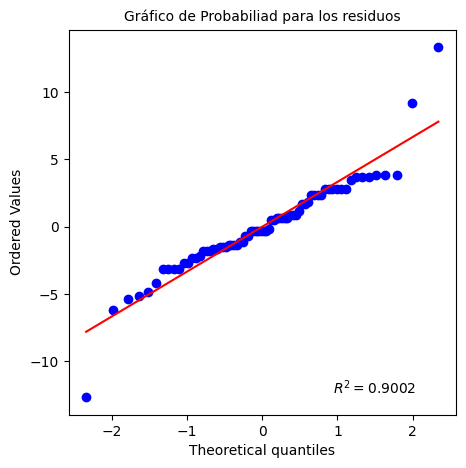

In [97]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloD3F.resid, plot= plt, rvalue= True)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
# Removed the problematic 'ax.set' line


plt.show()

[⬆️ Volver al inicio](#inicio)

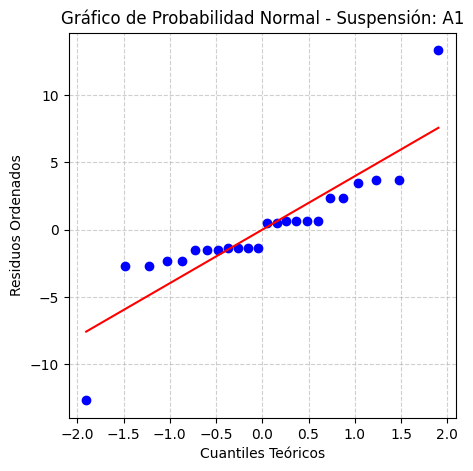

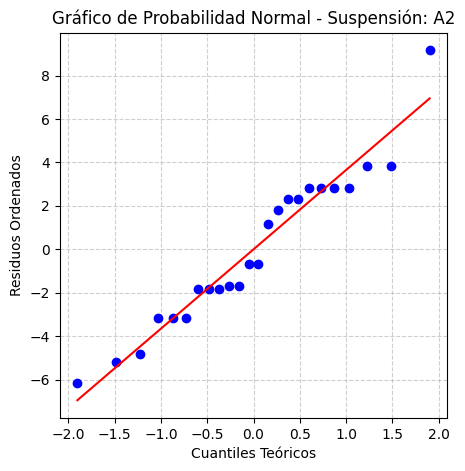

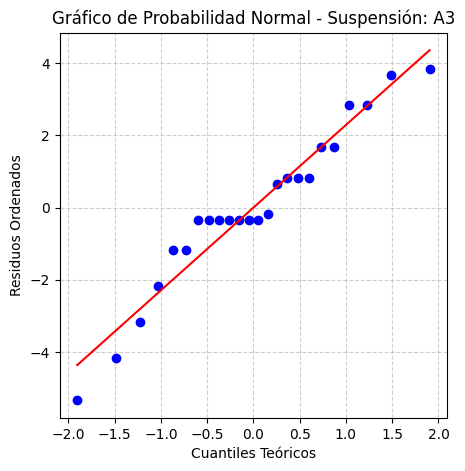

In [99]:
# @title **C. Prueba gráfica con el gráfico de probabilidad Normal por niveles de Suspensión**
import matplotlib.pyplot as plt
import scipy.stats as stats

# Get unique levels of the Suspension factor
unique_suspensions = D3F['Suspension'].unique()

# Get residuals from the fitted model
residuals = modeloD3F.resid

# Loop through each Suspension level and plot the residuals
for suspension_level in unique_suspensions:
    # Filter residuals for the current Suspension level
    level_residuals = residuals[D3F['Suspension'] == suspension_level]

    plt.figure(figsize=(5, 5))
    stats.probplot(level_residuals, dist="norm", plot=plt)
    plt.title(f"Gráfico de Probabilidad Normal - Suspensión: {suspension_level}")
    plt.xlabel("Cuantiles Teóricos")
    plt.ylabel("Residuos Ordenados")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

[⬆️ Volver al inicio](#inicio)

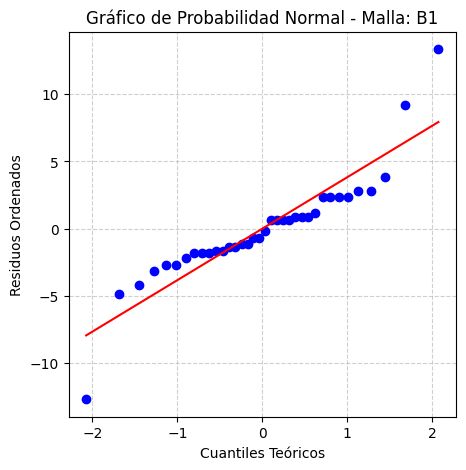

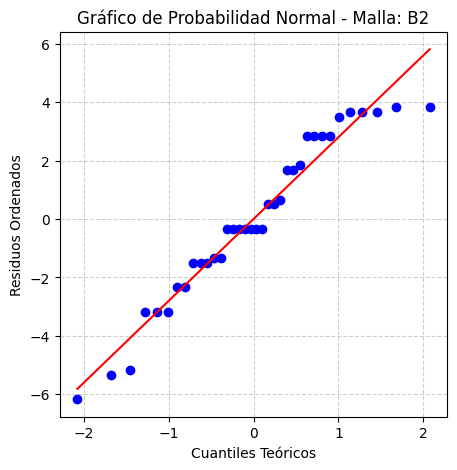

In [102]:
# @title **D. Prueba gráfica con el gráfico de probabilidad Normal por niveles de Malla**
import matplotlib.pyplot as plt
import scipy.stats as stats

# Get unique levels of the Malla factor
unique_mallas = D3F['Malla'].unique()

# Get residuals from the fitted model
residuals = modeloD3F.resid

# Loop through each Malla level and plot the residuals
for malla_level in unique_mallas:
    # Filter residuals for the current Malla level
    level_residuals = residuals[D3F['Malla'] == malla_level]

    plt.figure(figsize=(5, 5))
    stats.probplot(level_residuals, dist="norm", plot=plt)
    plt.title(f"Gráfico de Probabilidad Normal - Malla: {malla_level}")
    plt.xlabel("Cuantiles Teóricos")
    plt.ylabel("Residuos Ordenados")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

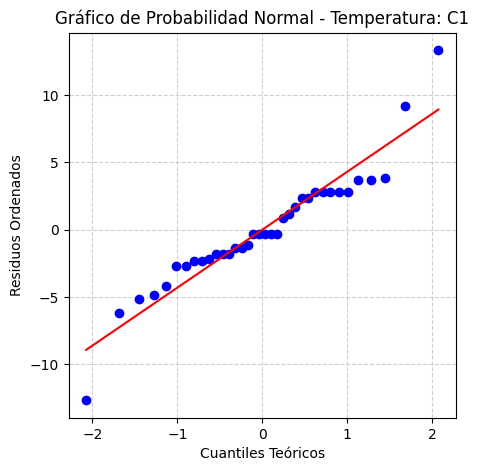

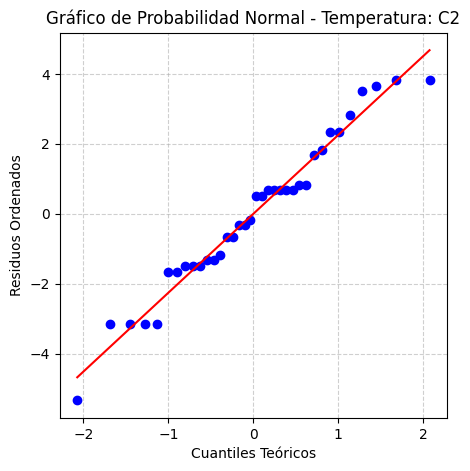

In [103]:
# @title **E. Prueba gráfica con el gráfico de probabilidad Normal por niveles de Temperatura**
import matplotlib.pyplot as plt
import scipy.stats as stats

# Get unique levels of the Temperatura factor
unique_temperaturas = D3F['Temperatura'].unique()

# Get residuals from the fitted model
residuals = modeloD3F.resid

# Loop through each Temperatura level and plot the residuals
for temperatura_level in unique_temperaturas:
    # Filter residuals for the current Temperatura level
    level_residuals = residuals[D3F['Temperatura'] == temperatura_level]

    plt.figure(figsize=(5, 5))
    stats.probplot(level_residuals, dist="norm", plot=plt)
    plt.title(f"Gráfico de Probabilidad Normal - Temperatura: {temperatura_level}")
    plt.xlabel("Cuantiles Teóricos")
    plt.ylabel("Residuos Ordenados")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. Supuestos del Modelo = Homocedasticidad**


In [104]:
# @title **A. Supuestos del Modelo = Homocedasticidad (Levene para Suspension)**
import scipy.stats as stats

suspension_groups = [D3F['volumen'][D3F['Suspension'] == susp] for susp in D3F['Suspension'].unique()]
L1 = stats.levene(*suspension_groups)

print(f'El valor critico levene es {round(L1[0],3)} y el valor p = {round(L1[1],3)}') # Use 0.05 for p-value comparison

El valor critico levene es 0.504 y el valor p = 0.606


[⬆️ Volver al inicio](#inicio)

In [105]:
# @title **B. Homocedasticidad de los residuos: Malla**
import scipy.stats as stats

malla_groups = [D3F['volumen'][D3F['Malla'] == malla] for malla in D3F['Malla'].unique()]
L2 = stats.levene(*malla_groups)

print(f'El valor critico levene es {round(L2[0],3)} y el valor p = {round(L2[1],3)}')

El valor critico levene es 1.896 y el valor p = 0.173


[⬆️ Volver al inicio](#inicio)

In [106]:
# @title **C. Homocedasticidad de los residuos: Temperatura**
import scipy.stats as stats

temperatura_groups = [D3F['volumen'][D3F['Temperatura'] == temp] for temp in D3F['Temperatura'].unique()]
L3 = stats.levene(*temperatura_groups)

print(f'El valor critico levene es {round(L3[0],3)} y el valor p = {round(L3[1],3)}')

El valor critico levene es 0.069 y el valor p = 0.794


<a name="T14"></a>
## **14. Supuestos del Modelo = Independencia**

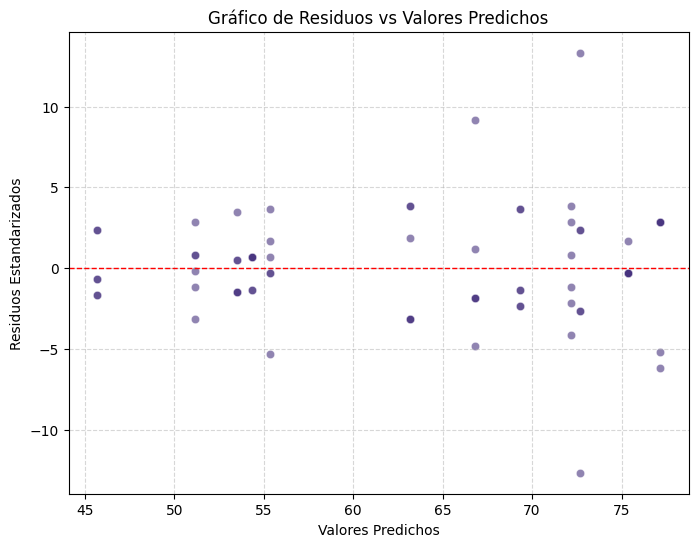

Interpretación:
- Si los puntos se dispersan aleatoriamente alrededor de la línea horizontal en 0, sugiere que el supuesto de homocedasticidad se cumple.
- Si los puntos forman un patrón (por ejemplo, forma de cono, embudo), sugiere heterocedasticidad (varianzas no homogéneas).


In [109]:
# @title **A. Gráfico de Residuos vs Valores Predichos para Homocedasticidad**

import matplotlib.pyplot as plt
import seaborn as sns

# Obtener residuos y valores predichos del modelo ANOVA (modeloD3F)
residuals = modeloD3F.resid
predicted_values = modeloD3F.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=predicted_values, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', lw=1) # Línea de referencia en 0
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos Estandarizados") # O simplemente "Residuos" si no están estandarizados
plt.title("Gráfico de Residuos vs Valores Predichos")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Interpretación:")
print("- Si los puntos se dispersan aleatoriamente alrededor de la línea horizontal en 0, sugiere que el supuesto de homocedasticidad se cumple.")
print("- Si los puntos forman un patrón (por ejemplo, forma de cono, embudo), sugiere heterocedasticidad (varianzas no homogéneas).")

In [ ]:
# @title **A. Gráfico de Residuos vs Valores Predichos para Homocedasticidad**

import matplotlib.pyplot as plt
import seaborn as sns

# Obtener residuos y valores predichos del modelo ANOVA (modeloD3F)
residuals = modeloD3F.resid
predicted_values = modeloD3F.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=predicted_values, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', lw=1) # Línea de referencia en 0
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos Estandarizados") # O simplemente "Residuos" si no están estandarizados
plt.title("Gráfico de Residuos vs Valores Predichos")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Interpretación:")
print("- Si los puntos se dispersan aleatoriamente alrededor de la línea horizontal en 0, sugiere que el supuesto de homocedasticidad se cumple.")
print("- Si los puntos forman un patrón (por ejemplo, forma de cono, embudo), sugiere heterocedasticidad (varianzas no homogéneas).")

In [110]:
# @title **B. Prueba de Durbin-Watson para Independencia de Residuos**

from statsmodels.stats.stattools import durbin_watson

# Obtener los residuos del modelo ANOVA
residuals = modeloD3F.resid

# Calcular el estadístico de Durbin-Watson
dw_statistic = durbin_watson(residuals)

print(f"Estadístico de Durbin-Watson: {dw_statistic:.4f}")

print("\nInterpretación del estadístico de Durbin-Watson:")
print("- Un valor cercano a 2 sugiere que no hay autocorrelación.")
print("- Valores significativamente menores que 2 sugieren autocorrelación positiva.")
print("- Valores significativamente mayores que 2 sugieren autocorrelación negativa.")
# Se pueden consultar tablas para valores críticos exactos según el número de observaciones y predictores.
print("\nNota: Para una interpretación precisa, compara este valor con las tablas de Durbin-Watson o considera pruebas alternativas.")

Estadístico de Durbin-Watson: 2.0565

Interpretación del estadístico de Durbin-Watson:
- Un valor cercano a 2 sugiere que no hay autocorrelación.
- Valores significativamente menores que 2 sugieren autocorrelación positiva.
- Valores significativamente mayores que 2 sugieren autocorrelación negativa.

Nota: Para una interpretación precisa, compara este valor con las tablas de Durbin-Watson o considera pruebas alternativas.


In [ ]:
# @title **B. Prueba de Durbin-Watson para Independencia de Residuos**

from statsmodels.stats.stattools import durbin_watson

# Obtener los residuos del modelo ANOVA
residuals = modeloD3F.resid

# Calcular el estadístico de Durbin-Watson
dw_statistic = durbin_watson(residuals)

print(f"Estadístico de Durbin-Watson: {dw_statistic:.4f}")

print("\nInterpretación del estadístico de Durbin-Watson:")
print("- Un valor cercano a 2 sugiere que no hay autocorrelación.")
print("- Valores significativamente menores que 2 sugieren autocorrelación positiva.")
print("- Valores significativamente mayores que 2 sugieren autocorrelación negativa.")
# Se pueden consultar tablas para valores críticos exactos según el número de observaciones y predictores.
print("\nNota: Para una interpretación precisa, compara este valor con las tablas de Durbin-Watson o considera pruebas alternativas.")

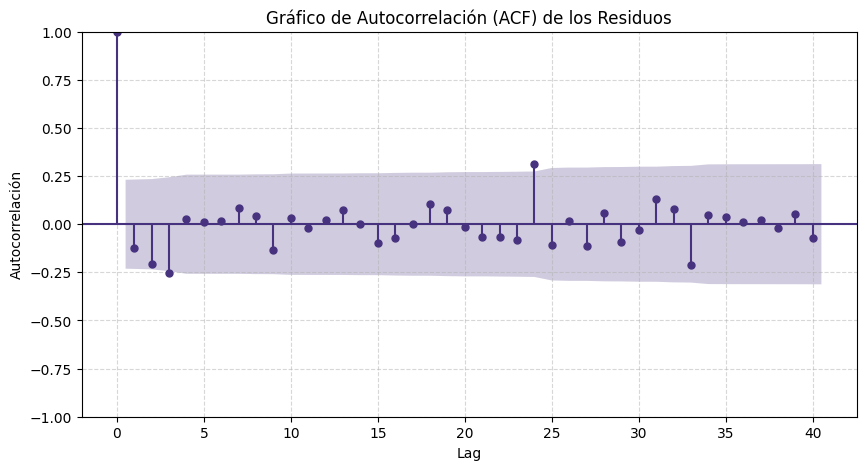

Interpretación:
- Las barras que se extienden significativamente por encima o por debajo de las líneas azules indican autocorrelación en ese lag.
- Si la mayoría de las barras están dentro de las líneas azules, sugiere que no hay autocorrelación significativa.


In [111]:
# @title **C. Gráfico de Autocorrelación (ACF) para Residuos**

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Obtener los residuos del modelo ANOVA
residuals = modeloD3F.resid

# Crear el gráfico de autocorrelación
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=40, ax=plt.gca()) # Puedes ajustar 'lags' según el número de observaciones
plt.title("Gráfico de Autocorrelación (ACF) de los Residuos")
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Interpretación:")
print("- Las barras que se extienden significativamente por encima o por debajo de las líneas azules indican autocorrelación en ese lag.")
print("- Si la mayoría de las barras están dentro de las líneas azules, sugiere que no hay autocorrelación significativa.")